# FPL Forecasting & Squad Optimization — Notebook Overview

This notebook presents an end-to-end workflow that (1) **forecasts player performance**, (2) **optimizes a starting XI under FPL rules and budget**, (3) **builds a bench**, and (4) **simulates team points for upcoming gameweeks** (with optional **rolling re-optimization**). It uses deterministic tie-breakers and stability-focused settings to ensure reproducible selections and results.

## What the notebook does

1. **Data setup**

   * Loads `merged_gw_2324.csv` and scales player values (`value /= 10`) to match FPL pricing.
   * Produces a modeling view `df_filtered` by dropping non-predictive or leakage columns.
   * Keeps a small EDA view (`simple_df`) for quick sanity checks.

2. **Forecasting methods (per-player)**

   * `average()` supports:

     * **Simple / Weighted** averages
     * **Simulation (non-parametric bootstrap)**
     * **Monte Carlo (Normal)**
     * **ARIMA** (order configurable, e.g., `(0,0,1)`)
     * **Linear Regression** trend extrapolation
     * **Exponential Smoothing**
   * `calling_average()` applies the chosen method across all players, returning:

     * `expected points` and an uncertainty proxy (`std`) plus current `value`, `position`, `team`.

3. **Hybrid feature forecasts (per-player, per-metric)**

   * `hybrid_average()` forecasts multiple numeric columns (e.g., `expected_assists`, `ict_index`, etc.) using the same families of methods (weighted, LR, ES, bootstrap, MC, ARIMA).
   * `calling_hybrid_average()` aggregates those forecasts per player.
   * `hybrid_weighting()` fits a **Ridge** model by position to turn hybrid features into a consolidated **`hybrid_points`** score (normalized blend with weights `a` and `b`).

4. **Optimization (starting XI + captain)**

   * `starting_eleven()` builds a **Pyomo** model with:

     * Budget, formation bounds, captain selection, and **≤3 players per team** constraints.
     * Objective variants: `expected`, `hybrid`, `ICT`, `involvement`, and **robust** versions (score − uncertainty).
     * A tiny deterministic tie-breaker to ensure stable solutions.
   * Solved with **GLPK** (set via `pyo.SolverFactory("glpk")`).

5. **Bench construction**

   * `bench()` selects a bench that complements the starting XI:

     * Meets bench position requirements.
     * Obeys budget (100 − starting budget) and team limits.
     * Uses stable sorting to break ties on equal expected points.

6. **Simulation**

   * `next_week()` computes realized team points from GW = `gameweek` to 38, with captain double points and **automatic bench substitution** when starters do not play.
   * `rolling()` re-ranks squad vs. bench each week using current expectations (optionally via the same method as your baseline), respecting formation limits and stable tie-breaking.

7. **Experiment runners**

   * `_run_expected`, `_run_expected_with_rolling`, `_run_ICT`, `_run_hybrid`, `_run_involvement`, `_run_linear_baseline` orchestrate end-to-end experiments.
   * The bottom section executes a **battery of runs**:

     * Multiple methods (Simple, Weighted, ES, Bootstrap, MC, ARIMA with sweeps, LR).
     * Robust variants.
     * Hybrid and ICT blends with different `(a, b)` weights.
     * Budget sweeps.
     * Rolling variants.
   * Each run appends its series of weekly totals to **`Results.csv`** (one column per experiment, in execution order).

## Key parameters to know

* `gameweek`: the split point between train/test (default `27`).
* `budget`: typically `83.5`, but many sweeps use `[80, 75, 70, 65, 60, 55]`.
* `arima_order`: e.g., `(0,0,1)`, `(1,0,0)`, `(1,0,1)`, etc.
* `a, b`: hybrid weighting blend (e.g., `a=2, b=1` or `a=1, b=2`).
* Random seeds for bootstrap/MC are fixed for **reproducibility**.

## Outputs

* **`Results.csv`** — each experiment writes one column of team totals across future gameweeks (labels match run names).
* Console prints for:

  * Selected XI + **captain**
  * Bench order
  * Weekly/total points (baseline and rolling)

## Requirements

* Python libraries: `pandas`, `numpy`, `statsmodels`, `scikit-learn`, `pyomo`, `matplotlib`, `seaborn` (for EDA).
* **Solver**: GLPK must be installed and available on PATH (`glpsol`).

  * Example (Ubuntu): `sudo apt-get install glpk-utils`
  * Windows/macOS: install GLPK and ensure `glpsol` is discoverable by Pyomo.

## How to use

1. Place `merged_gw_2324.csv` in the working directory.
2. Run the notebook top-to-bottom.

   * Modify `gameweek`, `budget`, method names, `arima_order`, and `(a, b)` in the runner cells to explore alternatives.
3. Inspect **`Results.csv`** for consolidated experiment outcomes.


##Run the following cell before the next one only if you are using google colab

In [ ]:
GOOGLE_COALB = False

In [ ]:
GOOGLE_COALB = True
from google.colab import files
uploaded = files.upload()
!apt-get install -y glpk-utils

In [5]:
# --- Setup & Data Load (from original Cell 1 + minimal tidy) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Load data (same file + same scaling)
df = pd.read_csv('merged_gw_2324.csv')
df['value'] = df['value'] / 10

# Keep a filtered view exactly as in your original Cell 1
columns_to_exclude_ML = ['xP','bonus','bps','element','creativity','fixture','influence',
                         'kickoff_time','opponent_team','round','team_a_score', 'team_h_score',
                         'threat','transfers_balance', 'transfers_in','transfers_out',
                         'was_home','yellow_cards','red_cards','penalties_missed','goals_conceded','GW',
                         'goals_scored', 'assists', 'clean_sheets', 'minutes', 'saves', 'yellow_cards',
                         'red_cards', 'penalties_missed', 'penalties_saved', 'own_goals', 'bonus']
df_filtered = df.drop(columns=columns_to_exclude_ML, errors='ignore')

# Simple EDA view (from original Cell 3, kept optional)
columns_to_keep = ['name','position','team','value','total_points']
simple_df = df[columns_to_keep]
simple_df.head()


# Cell 2

# --- Original functions (Cells 4–13) kept VERBATIM except deterministic tie-break tweaks where noted ---

# Cell 4: split + imports for time series models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore", category=Warning, module="statsmodels")

# Spliting data
gameweek = 27 #gameweek 27
for index, row in df.iterrows():
  if row['GW'] == gameweek:
    idx = index
    break
train,test = df_filtered[:idx],df[idx:] #traditional method

# Cell 5: average() as-is
import numpy as np
import math
from scipy.stats import poisson

def average(points, method, arima_order=(0, 0, 1)):
  #simple average
  if method == 'simple':
    return points.mean()
  elif method == 'weighted':
    # Generate weights: most recent row gets the highest weight
    weights = np.arange(1, len(points) + 1)  # 1 to N (older to newer)
    weights = weights / weights.sum()  # normalize weights to sum to 1
    return (points.multiply(weights, axis=0)).sum()
  elif method == 'simulation-non parametric':
    num_simulations=1000
    np.random.seed(54) #99=569
    return np.random.choice(points, size=num_simulations, replace=True).mean()
  elif method == 'monte carlo':
    num_simulations=1000 #previous 10000

    mean_score = np.mean(points)
    std_score = np.std(points, ddof=1)  # unbiased estimator
    if math.isnan(mean_score) or math.isnan(std_score):
      return 0
    np.random.seed(123) #123=545
    return np.random.normal(mean_score, std_score, num_simulations).mean()
  elif method == 'arima':
    # print(arima_order)
    if len(points) < 2 or points.mean()==0:
      return points.mean()  # Fall back to mean (or last value)
    try:
        model = ARIMA(points, order=arima_order) #best = 001
        model_fit = model.fit()
        predictions = model_fit.forecast(steps=38 - gameweek)

        return predictions.mean()  # or whatever you want to do with the forecast
    except Exception as e:
          print("ARIMA failed:", e)
          return points.mean()

  elif method == 'linear regression':
    if len(points) < 2 or points.mean()==0:
        return points.mean()  # Fall back to mean (or last value)
    try:
      # Create weeks array matching the length of points
      weeks = np.arange(1, len(points) + 1).reshape(-1, 1)
      scores = np.array(points)
      # Fit the model
      reg = LinearRegression()
      reg.fit(weeks, scores)

      # Predict from next week up to GW38
      future_weeks = np.arange(len(points) + 1, 39).reshape(-1, 1)
      predictions = reg.predict(future_weeks)
      return predictions.mean()
    except Exception as e:
      print("linear regression failed:", e)
      return points.mean()
  elif method == 'cvar':
    return points.to_numpy()
  elif method == 'exponential smoothing':
    if len(points) < 2:
      return points.mean()  # Fall back to mean (or last value)
    model = ExponentialSmoothing(points, trend='add')
    fit = model.fit()
    predictions = fit.forecast(38-gameweek)
    return predictions.mean()
  else:
    raise ValueError(f"Unknown method: {method}")

# Cell 6: calling_average() as-is
names = train['name'].unique()
import math
def calling_average(train, method, arima_order = (0,0,1)):
  names = train['name'].unique()
  scores = []
  count = 0
  method__ = method
  for name in names:
    count+=1
    points = train[train['name'] == name]['total_points']
    last_value = train[train['name'] == name]['value'].iloc[-1]
    average_ = average(points,method=method__, arima_order = arima_order) #prediction method
    sd = points.std()
    if math.isnan(sd):
      sd = 500
    position = train[train['name'] == name]['position'].iloc[-1]
    team = train[train['name'] == name]['team'].iloc[-1]
    scores.append({
          'name': name,
          'team': team,
          'position': position,
          'expected points': average_,
          'uncertainty': sd,
          'value': last_value
      })
  return pd.DataFrame(scores)

# Cell 7: hybrid_average/calling_hybrid_average as-is
import math
def hybrid_average(points, method):
  if method == 'simple average':
    return points.mean()
  elif method == 'linear regression':
      forecasts = {}
      numeric_cols = points.select_dtypes(include='number').columns

      for col in numeric_cols:
          col_data = points[col]
          if len(col_data) < 2 or col_data.mean() == 0:
              forecasts[col] = col_data.mean()  # fallback to mean
          else:
              try:
                  # Create weeks array matching the length of points
                  weeks = np.arange(1, len(col_data) + 1).reshape(-1, 1)
                  scores = col_data.values.reshape(-1, 1)
                  reg = LinearRegression()
                  reg.fit(weeks, scores)

                  # Predict from next week up to GW38
                  future_weeks = np.arange(len(col_data) + 1, 39).reshape(-1, 1)
                  predictions = reg.predict(future_weeks)
                  forecasts[col] = predictions.mean()
              except Exception as e:
                  print(f"Linear regression failed for {col}: {e}")
                  forecasts[col] = col_data.mean()  # fallback if regression fails

      return pd.Series(forecasts)
  if method == 'simple ICT':
        # Return a Series with 'ict_index' and mean for other numeric columns
        forecasts = {}
        forecasts['ict_index'] = points['ict_index'].mean()
        for col in points.select_dtypes(include='number').columns:
            if col != 'ict_index':
                forecasts[col] = points[col].mean()
        return pd.Series(forecasts)
  elif method == 'exponential smoothing':
    forecasts = {}
    numeric_cols = points.select_dtypes(include='number').columns

    for col in numeric_cols:
        col_data = points[col].dropna()
        if len(col_data) < 2:
            forecasts[col] = col_data.mean()
            continue
        try:
            model = ExponentialSmoothing(col_data, trend='add', initialization_method="estimated")
            fit = model.fit()
            steps = max(1, 38 - gameweek)  # safeguard against negative/zero
            predictions = fit.forecast(steps)
            forecasts[col] = predictions.mean()
        except Exception as e:
            print(f"Exponential smoothing failed for {col}: {e}")
            forecasts[col] = col_data.mean()

    return pd.Series(forecasts)
  elif method == 'simulation-non parametric':
    num_simulations = 1000
    forecasts = {}
    numeric_cols = points.select_dtypes(include='number').columns

    for col in numeric_cols:
        col_data = points[col].dropna()
        if len(col_data) == 0:
            forecasts[col] = 0
            continue
        try:
            np.random.seed(54)  # reproducibility
            simulated_values = np.random.choice(col_data, size=num_simulations, replace=True)
            forecasts[col] = simulated_values.mean()
        except Exception as e:
            print(f"Non-parametric simulation failed for {col}: {e}")
            forecasts[col] = col_data.mean()

    return pd.Series(forecasts)

  elif method == 'monte carlo':
      num_simulations = 1000  # previous 10000
      forecasts = {}
      numeric_cols = points.select_dtypes(include='number').columns

      for col in numeric_cols:
          col_data = points[col].dropna()
          mean_score = np.mean(col_data)
          std_score = np.std(col_data, ddof=1)  # unbiased estimator

          if math.isnan(mean_score) or math.isnan(std_score) or len(col_data) < 2:
              forecasts[col] = mean_score if not math.isnan(mean_score) else 0
          else:
              try:
                  np.random.seed(123)  # reproducibility
                  simulated = np.random.normal(mean_score, std_score, num_simulations)
                  forecasts[col] = simulated.mean()
              except Exception as e:
                  print(f"Monte Carlo failed for {col}: {e}")
                  forecasts[col] = mean_score

      return pd.Series(forecasts)
  if method == 'arima':
        # Only forecast 'total_points' with ARIMA
        forecasts = {}
        if len(points['total_points']) < 2 or points['total_points'].mean() == 0:
            # Fall back to mean for all numeric columns
            return points.mean()
        try:
            model = ARIMA(points['total_points'], order=(0,0,1))  # best = 011
            model_fit = model.fit()
            predictions = model_fit.forecast(steps=38 - gameweek)
            # Return as Series with 'total_points' and all other numeric columns
            forecasts['total_points'] = predictions.mean()
            for col in points.select_dtypes(include='number').columns:
                if col != 'total_points':
                    forecasts[col] = points[col].mean()  # fallback to mean for other columns
            return pd.Series(forecasts)
        except Exception as e:
            print("ARIMA failed:", e)
            # Return mean for all numeric columns if ARIMA fails
            return points.mean()
  elif method == 'weighted':
    # Create weights that increase over time (more recent = higher weight)
    weights = np.arange(1, len(points) + 1)

    # Apply weighted average for each column
    weighted_avg = (points.multiply(weights, axis=0)).sum() / weights.sum()

    return weighted_avg

def calling_hybrid_average(train, method):
  names = train['name'].unique()
  scores = []
  for name in names:
    points = train[train['name'] == name]
    last_value = train[train['name'] == name]['value'].iloc[-1]
    average_ = hybrid_average(points.select_dtypes(include='number'),method=method) #prediction method
    sd_ICT   = points['ict_index'].std()
    if math.isnan(sd_ICT):
      sd_ICT = 500
    position = train[train['name'] == name]['position'].iloc[-1]
    team = train[train['name'] == name]['team'].iloc[-1]
    scores.append({
          'name': name,
          'team': team,
          'position': position,
          "ICT_uncertainty":sd_ICT,
          'value': last_value
      })
    scores_temp = {}
    for item in average_.keys():
      if item != 'value':
        scores_temp[item] = average_[item]
    scores[-1].update(scores_temp)

  return pd.DataFrame(scores)

# Cell 8: hybrid_weighting() as-is
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge  # instead of LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
def hybrid_weighting(scores_df_,a,b):
  # We'll create a new column for hybrid points
  scores_df_['hybrid_points'] = 0.0

  # Define the target and feature columns (only numeric and useful ones)
  feature_cols = [
      'expected_assists', 'expected_goal_involvements', 'expected_goals',
      'expected_goals_conceded', 'ict_index', 'selected', 'starts',
      'total_points'  # include total_points for now, we'll drop it when modeling
  ]

  # Process for each position
  for position in scores_df_['position'].unique():
      df_pos = scores_df_[scores_df_['position'] == position].copy()

      # Drop rows with NaNs
      df_pos = df_pos.dropna(subset=feature_cols)

      # Define X and y
      X = df_pos[feature_cols].drop(columns=['total_points'])
      y = df_pos['total_points']

      # Normalize features to prevent large coefficients
      scaler = StandardScaler()
      X_scaled = scaler.fit_transform(X)

      # Fit Ridge regression (L2 regularization)
      # model = LinearRegression(fit_intercept=False)
      model = Ridge(alpha=1.0, fit_intercept=False)  # alpha controls strength of regularization (higher = more regularization)
      model.fit(X_scaled, y)

      # Get predictions and scale them
      y_pred = model.predict(X)
      # Normalize predictions to [0, 1] range for fair combination
      y_pred_normalized = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())

      # # Get total_points also scaled to [0, 1]
      total_points_scaled = (y - y.min()) / (y.max() - y.min())

      # Combine with 2:1 ratio (total_points has double weight)
      hybrid = (a * total_points_scaled + b * y_pred_normalized) / 3 #a=2 b= 1
      # hybrid = (1 * y + 2 * y_pred) / 3 # with no intercept
      # Map back to the scores_df by index
      scores_df_.loc[df_pos.index, 'hybrid_points'] = hybrid * y.max()  # scale back to similar magnitude
  return scores_df_

# Cell 9: Optimization model (starting XI) with deterministic tie-breaker
import pyomo.environ as pyo
import pandas as pd
from collections import defaultdict

def starting_eleven(scores_df, obj, scores_df_=None, budget = 83.5):
  print('starting eleven: \n')

  # Ensure contiguous integer index so j aligns with .loc[j, ...]
  scores_df = scores_df.reset_index(drop=True)

  # Mapping position to indices (optional, for display only)
  position_map = {"GK": 0, "DEF": 1, "MID": 2, "FWD": 3}

  # Group players by team
  teams = scores_df["team"].unique()
  team_players = defaultdict(list)
  for idx, row in scores_df.iterrows():
      team_players[row["team"]].append(idx)

  # Model setup
  model = pyo.ConcreteModel()
  n_players = len(scores_df)

  budget = budget #83.5
  num_players = 11

  # Decision variable: Binary (1 if player j is selected, 0 otherwise)
  model.x = pyo.Var(range(n_players), domain=pyo.Binary) #players
  model.y = pyo.Var(range(n_players), domain=pyo.Binary) #1 if captain is player j

  # Tiny deterministic tie-breaker (favor lower-index players consistently)
  eps = 1e-6
  def tie_term(model):
      return eps * sum((n_players - j) * (model.x[j] + model.y[j]) for j in range(n_players))

  # Objective function: Maximize total score (+ tie-term)
  def Obj(model):
    if obj == 'expected':
      return (
        sum(scores_df.loc[j, "expected points"] * model.x[j] for j in range(n_players)) +
        sum(scores_df.loc[j, "expected points"] * model.y[j] for j in range(n_players)) +
        tie_term(model)
      )
    if obj == 'hybrid':
      return (
        sum(scores_df_.loc[j, "hybrid_points"] * model.x[j] for j in range(n_players)) +
        sum(scores_df_.loc[j, "hybrid_points"] * model.y[j] for j in range(n_players)) +
        tie_term(model)
      )
    if obj == 'ICT':
      return (
        sum(scores_df_.loc[j, "ict_index"] * model.x[j] for j in range(n_players)) +
        sum(scores_df_.loc[j, "ict_index"] * model.y[j] for j in range(n_players)) +
        tie_term(model)
      )
    if obj == 'involvement':
      return (sum(scores_df_.loc[j, "expected_goal_involvements"] * model.x[j]
      for j in range(n_players)) + sum(scores_df_.loc[j, "expected_goal_involvements"] * model.y[j] for j in range(n_players)) - (sum
      (scores_df_.loc[j, "expected_goals_conceded"] * model.x[j]
      for j in range(n_players)) + sum(scores_df_.loc[j, "expected_goals_conceded"] * model.y[j] for j in range(n_players)) ) +
        tie_term(model)
      )
    if obj == 'robust expected':
        return sum(
          (scores_df.loc[j, "expected points"] - scores_df.loc[j, "uncertainty"])
          * (model.x[j] + model.y[j])
          for j in range(n_players)
      ) + tie_term(model)
    if obj == 'robust ICT':
        return sum(
          (scores_df_.loc[j, "ict_index"] - scores_df_.loc[j, "ICT_uncertainty"])
          * (model.x[j] + model.y[j])
          for j in range(n_players)
      ) + tie_term(model)

  model.obj = pyo.Objective(rule=Obj, sense=pyo.maximize)

  # Constraint 1: Exactly 11 players must be selected
  def Co1(model):
      return sum(model.x[j] for j in range(n_players)) == num_players
  model.Co1 = pyo.Constraint(rule=Co1)

  # Constraint 2: Budget ≤ cap
  def Co2(model):
      return sum(scores_df.loc[j, "value"] * model.x[j] for j in range(n_players)) <= budget
  model.Co2 = pyo.Constraint(rule=Co2)

  # Constraint 3: only select one captain
  def Co3(model):
      return sum(model.y[j] for j in range(n_players)) == 1
  model.Co3 = pyo.Constraint(rule=Co3)

  # Constraint 4: captain should be playing
  def Co4(model, j):
      return model.y[j] <= model.x[j]
  model.Co4 = pyo.Constraint(range(n_players), rule=Co4)

  # Constraint 5: Position-specific limits
  position_limits = {"GK": (1, 1), "DEF": (3, 5), "MID": (3, 5), "FWD": (1, 3)} #need to fill 2-5-5-3  = 15 players
  for position, (min_limit, max_limit) in position_limits.items():
      position_players = scores_df[scores_df["position"] == position].index.tolist()
      model.add_component(
          f"Min_{position}",
          pyo.Constraint(expr=sum(model.x[j] for j in position_players) >= min_limit)
      )
      model.add_component(
          f"Max_{position}",
          pyo.Constraint(expr=sum(model.x[j] for j in position_players) <= max_limit)
      )

  # Constraint 6: Maximum 3 players per team
  for team in teams:
      model.add_component(
          f"Max_Team_{team}",
          pyo.Constraint(expr=sum(model.x[j] for j in team_players[team]) <= 3)
      )

  # Solve the model
  if GOOGLE_COALB == True:
    solver = pyo.SolverFactory("glpk", executable="/usr/bin/glpsol")   # no hard-coded path
  else:
    solver = pyo.SolverFactory("glpk")
  solver.solve(model)

  # Display selected players
  selected_players = []
  captain          = []
  for j in range(n_players):
      if pyo.value(model.x[j]) > 0.5:  # Player is selected
          selected_players.append(scores_df.loc[j, ["name", "team", "position",  "value"]])
  for j in range(n_players):
      if pyo.value(model.y[j]) > 0.5:  # Player is selected
          captain.append(scores_df.loc[j, ["name", "team", "position",  "value"]])

  print(pd.DataFrame(selected_players),'\n','captain= ',pd.DataFrame(captain))
  return pd.DataFrame(selected_players), captain

# Cell 10: Bench optimizer with stable sorting
def bench(scores_df, selected_df, budget, n_players=len(names)):
  print('\n','--------------------------------------------', '\n','--------------------------------------------')
  teams = scores_df["team"].unique()
  bench_budget = 100 - budget

  # Count how many players per position are already in the starting XI
  num_starting = selected_df['position'].value_counts().to_dict()

  # How many per position we need on the bench
  bench_requirements = {
      "GK": 1,
      "DEF": 5 - num_starting.get("DEF", 0),
      "MID": 5 - num_starting.get("MID", 0),
      "FWD": 3 - num_starting.get("FWD", 0)
  }

  bench_model = pyo.ConcreteModel()
  bench_model.xb = pyo.Var(range(n_players), domain=pyo.Binary)

  def BenchObj(model):
      return sum(scores_df.loc[j, "expected points"] * model.xb[j] for j in range(n_players))
  bench_model.obj = pyo.Objective(rule=BenchObj, sense=pyo.maximize)

  for position, req in bench_requirements.items():
      position_players = scores_df[scores_df["position"] == position].index.tolist()
      bench_model.add_component(
          f"Bench_{position}",
          pyo.Constraint(expr=sum(bench_model.xb[j] for j in position_players) == req)
      )

  bench_model.budget_constraint = pyo.Constraint(
      expr=sum(scores_df.loc[j, "value"] * bench_model.xb[j] for j in range(n_players)) <= bench_budget
  )

  starting_counts = selected_df['team'].value_counts().to_dict()
  for team in teams:
      team_indices = scores_df[scores_df["team"] == team].index.tolist()
      already_selected = starting_counts.get(team, 0)
      bench_model.add_component(
          f"TeamLimit_{team}",
          pyo.Constraint(expr=sum(bench_model.xb[j] for j in team_indices) + already_selected <= 3)
      )

  already_selected_indices = selected_df.index.tolist()
  for idx in already_selected_indices:
      bench_model.add_component(
          f"NoOverlap_{idx}",
          pyo.Constraint(expr=bench_model.xb[idx] == 0)
      )

  if GOOGLE_COALB == True:
    solver = pyo.SolverFactory("glpk", executable="/usr/bin/glpsol")   # no hard-coded path
  else:
    solver = pyo.SolverFactory("glpk")
  solver.solve(bench_model)

  bench_players = []
  for j in range(n_players):
      if pyo.value(bench_model.xb[j]) > 0.5:
          bench_players.append(scores_df.loc[j, ["name", "team", "position", "value"]])

  bench_df = pd.DataFrame(bench_players)
  bench_df['expected_points'] = bench_df['name'].map(
      scores_df.set_index('name')['expected points']
  )
  # Stable, deterministic tie-break for equal expected_points
  bench_df_sorted = bench_df.sort_values(
      by=['expected_points', 'name'],
      ascending=[False, True],
      kind='mergesort'
  )
  print("Bench Squad sorted by expected points:\n", bench_df_sorted)
  return bench_df_sorted

# Cell 11: next_week as-is
def next_week(selected_df,captain, test, bench_df_sorted):
  print('\n','--------------------------------------------', '\n','--------------------------------------------')
  maximum_gameweeks = 38
  positions = ['GK', 'DEF', 'MID', 'FWD']

  array_holding_scores = []
  game_week_legend = []

  for gw in range(gameweek, maximum_gameweeks + 1):
      captain_name = captain[0]['name']
      team_score = 0
      captain_not_playing = False
      players_not_playing = []
      used_bench_players = set()  # reset per gameweek
      game_week_legend.append(gw)

      for idx, player in selected_df.iterrows():
          name = player['name']
          position = player['position']

          points_series = test[(test['name'] == name) & (test['GW'] == gw)]['total_points']
          if not points_series.empty:
              points = points_series.values[0]
              if name == captain_name:
                  points *= 2
              team_score += points
          else:
              players_not_playing.append(name)
              if name == captain_name:
                  captain_not_playing = True

              substituted = False
              for _, bench_player in bench_df_sorted.iterrows():
                  bench_name = bench_player['name']
                  bench_position = bench_player['position']

                  if bench_name in used_bench_players:
                      continue
                  if position != 'GK' and bench_position == 'GK':
                      continue

                  bench_points_series = test[(test['name'] == bench_name) & (test['GW'] == gw)]['total_points']
                  if not bench_points_series.empty:
                      team_score += bench_points_series.values[0]
                      used_bench_players.add(bench_name)
                      substituted = True
                      break

              if not substituted:
                  team_score += 0

      if captain_not_playing:
          eligible_players = selected_df[~selected_df['name'].isin(players_not_playing)]
          if not eligible_players.empty:
              eligible_players = eligible_players.copy()
              eligible_players['GW_points'] = eligible_players['name'].apply(
                  lambda n: test[(test['name'] == n) & (test['GW'] == gw)]['total_points'].values[0]
                  if not test[(test['name'] == n) & (test['GW'] == gw)]['total_points'].empty else 0
              )
              captain_name = eligible_players.loc[eligible_players['GW_points'].idxmax(), 'name']
              new_captain_points = eligible_players.loc[eligible_players['name'] == captain_name, 'GW_points'].values[0]
              team_score += new_captain_points
      array_holding_scores.append(team_score)
  print('performance of the team in the following weeks (no rolling window): \n',array_holding_scores,'\n', 'total points',sum(array_holding_scores) )
  return array_holding_scores

# Cell 12: rolling with stable sorting/tie-breaks in list building
def rolling(selected_df,bench_df_sorted,array_holding_scores, method = None):
  print('\n','--------------------------------------------', '\n','--------------------------------------------')
  import warnings
  warnings.simplefilter(action='ignore', category=Warning)
  import pandas as pd

  maximum_gameweeks = 38
  array_holding_scores_ = []
  game_week_legend = []
  weekly_lineups = []   # store starting XI / bench / swaps each GW
  temp_ = array_holding_scores[0]

  min_pos = {'DEF': 3, 'MID': 3, 'FWD': 1, 'GK': 1}
  max_pos = {'DEF': 5, 'MID': 5, 'FWD': 3, 'GK': 1}

  for gw in range(gameweek+1, maximum_gameweeks + 1):

      squad_df = selected_df.copy().reset_index(drop=True) #for normal
      bench_orig = bench_df_sorted.copy().reset_index(drop=True)
      team_score = 0
      players_not_playing = []
      game_week_legend.append(gw)

      upto = max(gw - 1, 0)
      exp_rows = []
      seen_names = set()
      for name in squad_df['name'].tolist() + bench_orig['name'].tolist():
          if name in seen_names:
              continue
          seen_names.add(name)
          if method == None:
            mean_points = df_filtered[df_filtered['name'] == name]['total_points'][:upto].mean()
          else:
            mean_points = average(df_filtered[df_filtered['name'] == name]['total_points'][:upto],method=method) #prediction method
          pos = df_filtered[df_filtered['name'] == name]['position'].iloc[0]
          exp_rows.append({'name': name, 'position': pos, 'expected': mean_points})
      exp_df = pd.DataFrame(exp_rows)

      bench_df = exp_df[exp_df['name'].isin(bench_orig['name'])].copy().reset_index(drop=True)
      bench_df = bench_df.sort_values(
          by=['expected','name'],
          ascending=[False, True],
          kind='mergesort'
      ).reset_index(drop=True)

      squad_df = squad_df.merge(exp_df[['name','expected']], on='name', how='left')

      pos_counts = squad_df['position'].value_counts().to_dict()

      def can_swap(starter_pos, bench_pos, pos_counts):
          new_counts = pos_counts.copy()
          new_counts[starter_pos] -= 1
          new_counts[bench_pos] = new_counts.get(bench_pos, 0) + 1
          for p in ['DEF','MID','FWD','GK']:
              if new_counts.get(p,0) < min_pos[p] or new_counts.get(p,0) > max_pos[p]:
                  return False
          return True

      changed = True
      while changed:
          changed = False
          for idx, starter in squad_df.iterrows():
              s_name = starter['name']
              s_pos = starter['position']
              s_expected = starter['expected'] if pd.notna(starter['expected']) else 0.0

              candidates = bench_df[bench_df['expected'] > s_expected].copy()
              candidates = candidates[candidates.apply(lambda x: can_swap(s_pos, x['position'], pos_counts), axis=1)]

              if not candidates.empty:
                  best = candidates.sort_values(
                      by=['expected','name'],
                      ascending=[False, True],
                      kind='mergesort'
                  ).iloc[0]
                  b_name, b_pos, b_expected = best['name'], best['position'], best['expected']

                  bench_df = bench_df[bench_df['name'] != b_name].reset_index(drop=True)
                  bench_df = pd.concat([bench_df, pd.DataFrame({'name':[s_name],'position':[s_pos],'expected':[s_expected]})], ignore_index=True)
                  bench_df = bench_df.sort_values(
                      by=['expected','name'],
                      ascending=[False, True],
                      kind='mergesort'
                  ).reset_index(drop=True)

                  squad_df.at[idx, 'name'] = b_name
                  squad_df.at[idx, 'position'] = b_pos
                  squad_df.at[idx, 'expected'] = b_expected

                  pos_counts[s_pos] -= 1
                  pos_counts[b_pos] = pos_counts.get(b_pos,0) + 1

                  changed = True
                  break

      starters = pd.DataFrame(columns=squad_df.columns)
      remaining = squad_df.copy()
      pos_selected = {p:0 for p in ['DEF','MID','FWD','GK']}

      while len(starters) < 11:
          candidate = remaining.sort_values(
              by=['expected','name'],
              ascending=[False, True],
              kind='mergesort'
          ).iloc[0]
          pos = candidate['position']
          if pos_selected[pos] < max_pos[pos]:
              starters = pd.concat([starters, pd.DataFrame([candidate])], ignore_index=True)
              pos_selected[pos] += 1
          remaining = remaining.drop(candidate.name)

      bench_candidates_final = pd.concat([remaining, bench_df], ignore_index=True).drop_duplicates(subset='name', keep='first')
      bench_order = bench_candidates_final.sort_values(
          by=['expected','name'],
          ascending=[False, True],
          kind='mergesort'
      ).reset_index(drop=True)

      orig_captain = captain[0]['name']
      if orig_captain in starters['name'].values:
          captain_name = orig_captain
      else:
          captain_name = starters.loc[starters['expected'].idxmax(), 'name']

      starting_11 = starters[['name','position','expected']].copy()
      bench_log = bench_order[['name','position','expected']].copy()

      used_bench = set()
      final_lineup_points = {}
      for _, st in starting_11.iterrows():
          n, pos = st['name'], st['position']
          pts_s = test[(test['name']==n) & (test['GW']==gw)]['total_points']
          if not pts_s.empty:
              final_lineup_points[n] = int(pts_s.values[0])
          else:
              sub_found = False
              for _, b in bench_order.iterrows():
                  bname, bpos = b['name'], b['position']
                  if bname in used_bench: continue
                  if pos != 'GK' and bpos == 'GK': continue
                  bpts_s = test[(test['name']==bname) & (test['GW']==gw)]['total_points']
                  if not bpts_s.empty:
                      final_lineup_points[bname] = int(bpts_s.values[0])
                      used_bench.add(bname)
                      sub_found = True
                      break
              if not sub_found:
                  final_lineup_points[n] = 0
                  players_not_playing.append(n)

      team_score = sum(final_lineup_points.values())
      if captain_name in final_lineup_points:
          team_score += final_lineup_points[captain_name]
      elif final_lineup_points:
          new_cap = max(final_lineup_points.items(), key=lambda x: x[1])[0]
          team_score += final_lineup_points[new_cap]

      array_holding_scores_.append(team_score)
      weekly_lineups.append({
          'GW': gw,
          'starting_11': starting_11,
          'bench': bench_log,
          'final_lineup_points': final_lineup_points,
          'team_score': team_score,
          'orig_captain': orig_captain,
          'captain_used': captain_name if captain_name in final_lineup_points else None
      })
  array_holding_scores_.insert(0,int(temp_))
  print('Performance of the team in the following weeks (rolling window): :', array_holding_scores_)
  print('Total score:', sum(array_holding_scores_))
  return array_holding_scores_

# Cell 13: saving() as-is
import os
def saving(col_name,array_holding_scores):
  print('\n','--------------------------------------------', '\n','--------------------------------------------')
  col_name = col_name
  if os.path.exists("Results.csv"):
      df_res = pd.read_csv("Results.csv")
      df_res[col_name] = array_holding_scores
  else:
      df_res = pd.DataFrame(array_holding_scores, columns=[col_name])
  df_res.to_csv("Results.csv", index=False)
  print('Result saved')


#Cell 3

# --- Driver helpers (no algorithm changes; only orchestration) ---

def run_expected(model_name, budget, method, arima_order=None):
    global scores_df
    if method == 'arima' and arima_order is not None:
        scores_df = calling_average(train, method=method, arima_order=arima_order)
    else:
        scores_df = calling_average(train, method=method)
    selected_df, captain = starting_eleven(scores_df, obj='expected', budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(model_name, arr)

def run_expected_with_rolling(model_name, budget, method, arima_order=None):
    global scores_df
    if method == 'arima' and arima_order is not None:
        scores_df = calling_average(train, method=method, arima_order=arima_order)
    else:
        scores_df = calling_average(train, method=method)
    selected_df, captain = starting_eleven(scores_df, obj='expected', budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    arr = rolling(selected_df, bench_df_sorted, arr)
    saving(model_name, arr)

def run_ICT(model_name, budget, method_for_expected, method_for_hybrid='weighted', robust=False):
    global scores_df, scores_df_
    scores_df = calling_average(train, method=method_for_expected)
    scores_df_ = calling_hybrid_average(train, method=('simple ICT' if method_for_hybrid=='simple ICT' else 'weighted'))
    obj = 'robust ICT' if robust else 'ICT'
    selected_df, captain = starting_eleven(scores_df, obj=obj, scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(model_name, arr)

def run_hybrid(model_name, budget, base_method, hybrid_method, a, b):
    global scores_df, scores_df_
    scores_df = calling_average(train, method=base_method)
    scores_df_ = calling_hybrid_average(train, method=hybrid_method)
    scores_df_ = hybrid_weighting(scores_df_, a, b)
    selected_df, captain = starting_eleven(scores_df, obj='hybrid', scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(model_name, arr)

def run_involvement(model_name, budget):
    global scores_df, scores_df_
    scores_df = calling_average(train, method='simple')
    scores_df_ = calling_hybrid_average(train, method='weighted')
    selected_df, captain = starting_eleven(scores_df, obj='involvement', scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(model_name, arr)

def run_linear_baseline(model_name, budget):
    # Mirrors Cell 48 exactly (computes hybrid but optimizes expected)
    global scores_df, scores_df_
    scores_df = calling_average(train, method='linear regression')
    scores_df_ = calling_hybrid_average(train, method='linear regression')
    scores_df_ = hybrid_weighting(scores_df_, 2, 1)
    selected_df, captain = starting_eleven(scores_df, obj='expected', scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(model_name, arr)


#Cell 4

# === Optimized experiment runner (in-place) ===
import pandas as pd

def _run_expected(label, budget, method, arima_order=None, robust=False):
    print('\n********',label,'********\n')
    if method == 'arima' and arima_order is not None:
        scores_df = calling_average(train, method=method, arima_order=arima_order)
    else:
        scores_df = calling_average(train, method=method)
    obj = 'robust expected' if robust else 'expected'
    selected_df, captain = starting_eleven(scores_df, obj=obj, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(label, arr)

def _run_ICT(label, budget, method_for_expected='simple', method_for_hybrid='weighted', robust=False):
    print('\n********',label,'********\n')
    scores_df  = calling_average(train, method=method_for_expected)
    scores_df_ = calling_hybrid_average(train, method=method_for_hybrid)
    obj = 'robust ICT' if robust else 'ICT'
    selected_df, captain = starting_eleven(scores_df, obj=obj, scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(label, arr)

def _run_involvement(label, budget):
    print('\n********',label,'********\n')
    scores_df  = calling_average(train, method='simple')
    scores_df_ = calling_hybrid_average(train, method='weighted')
    selected_df, captain = starting_eleven(scores_df, obj='involvement', scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(label, arr)

def _run_hybrid(label, budget, base_method, hybrid_method, a, b, arima_order=None):
    print('\n********',label,'********\n')
    if base_method == 'arima' and arima_order is not None:
        scores_df = calling_average(train, method=base_method, arima_order=arima_order)
    else:
        scores_df = calling_average(train, method=base_method)
    scores_df_ = calling_hybrid_average(train, method=hybrid_method)
    scores_df_ = hybrid_weighting(scores_df_.copy(), a=a, b=b)
    selected_df, captain = starting_eleven(scores_df, obj='hybrid', scores_df_=scores_df_, budget=budget)
    bench_df_sorted = bench(scores_df, selected_df, budget)
    arr = next_week(selected_df, captain, test, bench_df_sorted)
    saving(label, arr)

def _run_linear_baseline(label, budget):
    print('\n********',label,'********\n')
    _run_expected(label, budget, 'linear regression')

def _run_expected_with_rolling(label, budget, method, arima_order=None):
    print('\n********',label,'********\n')
    # Build expected/hybrid scores for the given method
    if method == 'arima':
        scores_df = calling_average(train, method=method, arima_order=arima_order)
    else:
        scores_df = calling_average(train, method=method)

    # Optimize starting XI
    selected_df, captain = starting_eleven(scores_df, obj='expected', budget=budget)

    # >>> IMPORTANT: make captain visible to rolling(), which reads it as a global
    globals()['captain'] = captain

    # Bench + simulate next week baseline
    bench_df_sorted = bench(scores_df, selected_df, budget)
    baseline = next_week(selected_df, captain, test, bench_df_sorted)

    # Rolling re-optimization uses the same method name that the original relied on
    rolled = rolling(
        selected_df,
        bench_df_sorted,
        baseline,
        # method=method if method != 'arima' else 'arima'
    )
    saving(label, rolled)

# Cells 14–22
_run_expected('Simple Avg.', 83.5, 'simple')
_run_expected('Weighted Avg.', 83.5, 'weighted')
_run_expected('Exponential Smoothing', 83.5, 'exponential smoothing')
_run_expected('Robust Simple Avg.', 83.5, 'simple', robust=True)
_run_expected('Robust Weighted Avg.', 83.5, 'weighted', robust=True)
_run_expected('Robust Exponential Smoothing', 83.5, 'exponential smoothing', robust=True)
_run_expected('Simulation (Non Parametric)', 83.5, 'simulation-non parametric')
_run_expected('Monte Carlo Simulation', 83.5, 'monte carlo')
_run_expected('ARIMA (0,0,1)', 83.5, 'arima', (0,0,1))

# Cells 23–30 (ARIMA sweep)
for label, order in [
    ('ARIMA (1,0,0)', (1,0,0)),
    ('ARIMA (0,1,1)', (0,1,1)),
    ('ARIMA (1,0,1)', (1,0,1)),
    ('ARIMA (1,1,0)', (1,1,0)),
    ('ARIMA (1,1,1)', (1,1,1)),
    ('ARIMA (2,1,1)', (2,1,1)),
    ('ARIMA (1,1,2)', (1,1,2)),
    ('ARIMA (2,1,2)', (2,1,2)),
]:
    _run_expected(label, 83.5, 'arima', order)

# Cells 31–33 (ICT & Involvement)
_run_ICT('ICT Score', 83.5, method_for_expected='simple', method_for_hybrid='weighted', robust=False)
_run_ICT('Robust ICT Score', 83.5, method_for_expected='simple', method_for_hybrid='weighted', robust=True)
_run_involvement('Involvement', 83.5)

# # Cells 34–41 (Hybrid Simple/Weighted/ES/Sim with 1:2 and 2:1)
_run_hybrid('Hybrid Simple Avg. 1:2 (Higher Total Points)', 83.5, base_method='simple', hybrid_method='simple average', a=2, b=1)
_run_hybrid('Hybrid Simple Avg. 2:1 (Lower Total Points)', 83.5, base_method='simple', hybrid_method='simple average', a=1, b=2)
_run_hybrid('Hybrid Weighted 1:2 (Higher Total Points)', 83.5, base_method='weighted', hybrid_method='weighted', a=2, b=1)
_run_hybrid('Hybrid Weighted 2:1 (Lower Total Points)', 83.5, base_method='weighted', hybrid_method='weighted', a=1, b=2)
_run_hybrid('Hybrid Exponential Smoothing 1:2 (Higher Total Points)', 83.5, base_method='exponential smoothing', hybrid_method='exponential smoothing', a=2, b=1)
_run_hybrid('Hybrid Exponential Smoothing 2:1 (Lower Total Points)', 83.5, base_method='exponential smoothing', hybrid_method='exponential smoothing', a=1, b=2)
_run_hybrid('Hybrid Simulation (Non Parametric) 1:2 (Higher Total Points)', 83.5, base_method='simulation-non parametric', hybrid_method='simulation-non parametric', a=2, b=1)
_run_hybrid('Hybrid Simulation (Non Parametric) 2:1 (Lower Total Points)', 83.5, base_method='simulation-non parametric', hybrid_method='simulation-non parametric', a=1, b=2)

# # Cells 42–45 (Hybrid MC/ARIMA)
_run_hybrid('Hybrid Monte Carlo 1:2 (Higher Total Points)', 83.5, base_method='monte carlo', hybrid_method='monte carlo', a=2, b=1)
_run_hybrid('Hybrid Monte Carlo 2:1 (Lower Total Points)', 83.5, base_method='monte carlo', hybrid_method='monte carlo', a=1, b=2)
_run_hybrid('Hybrid ARIMA 1:2 (Higher Total Points)', 83.5, base_method='arima', hybrid_method='arima', a=2, b=1, arima_order=(0,0,1))
_run_hybrid('Hybrid ARIMA 2:1 (Lower Total Points)', 83.5, base_method='arima', hybrid_method='arima', a=1, b=2, arima_order=(0,0,1))

# # Cells 46–47 (Hybrid ICT with weighting)
_run_hybrid('Hybrid ICT Score 1:2 (Higher Total Points)', 83.5, base_method='weighted', hybrid_method='simple ICT', a=2, b=1)
_run_hybrid('Hybrid ICT Score 2:1 (Lower Total Points)', 83.5, base_method='weighted', hybrid_method='simple ICT', a=1, b=2)

# # Cell 48–50 (Linear Regression + Hybrid LR)
_run_linear_baseline('Linear Regression', 83.5)
_run_hybrid('Hybrid Linear Regression 1:2 (Higher Total Points)', 83.5, base_method='linear regression', hybrid_method='linear regression', a=2, b=1)
_run_hybrid('Hybrid Linear Regression 2:1 (Lower Total Points)', 83.5, base_method='linear regression', hybrid_method='linear regression', a=1, b=2)

# # Cells 51–64 (Budget sweeps for Simple/Weighted)
for b in [75,80,65,55]:
    _run_expected(f'Simple Avg. (Budget = {b})', b, 'simple')
for b in [80,75,70,65,60]:
    _run_expected(f'Simple Avg. (Budget = {b})', b, 'weighted')
for b in [80,75,70,65,60]:
    _run_expected(f'Weighted Avg. (Budget = {b})', b, 'weighted')

# # Cells 65–78 (ARIMA (0,0,1) & (1,0,0) & (1,0,1) with budgets)
for b in [80,75,70,65]:
    _run_expected(f'ARIMA (0,0,1, Budget = {b})', b, 'arima', (0,0,1))
for b in [80,75,70,65,60]:
    _run_expected(f'ARIMA (1,0,0, Budget = {b})', b, 'arima', (1,0,0))
for b in [80,75,70,65,60]:
    _run_expected(f'ARIMA (1,0,1, Budget = {b})', b, 'arima', (1,0,1))

# # Cells 79–85 (ICT Score budgets + Hybrid ICT budgets)
for b in [80,75,70]:
    _run_ICT(f'ICT Score (Budget = {b})', b, method_for_expected='weighted', method_for_hybrid='simple ICT', robust=False)
for b in [80,75,70,65]:
    _run_hybrid(f'Hybrid ICT Score (Budget = {b})', b, base_method='weighted', hybrid_method='simple ICT', a=2, b=1)

# # Cells 86–90 (Monte Carlo budgets)
for b in [80,75,70,65,60]:
    _run_expected(f'Monte Carlo (Budget = {b})', b, 'monte carlo')

# # Cells 91–110 (Rolling variants)
_run_expected_with_rolling('ARIMA (1,0,0) Rolling', 83.5, 'arima', (1,0,0))
for b in [75,70,60]:
    _run_expected_with_rolling(f'ARIMA (1,0,0) Rolling (Budget = {b})', b, 'arima', (1,0,0))

_run_expected_with_rolling('ARIMA (1,0,1) Rolling', 83.5, 'arima', (1,0,1))
for b in [80,70,60]:
    _run_expected_with_rolling(f'ARIMA (1,0,1) Rolling (Budget = {b})', b, 'arima', (1,0,1))

_run_expected_with_rolling('Simple Avg. Rolling', 83.5, 'simple')
for b in [80,70,65]:
    _run_expected_with_rolling(f'Simple Avg. Rolling (Budget = {b})', b, 'simple')

_run_expected_with_rolling('Weighted Avg. Rolling', 83.5, 'weighted')
for b in [80,70,60]:
    _run_expected_with_rolling(f'Weighted Avg. Rolling (Budget = {b})', b, 'weighted')

_run_expected_with_rolling('ARIMA (0,0,1) Rolling', 83.5, 'arima', (0,0,1))
for b in [80,70,60]:
    _run_expected_with_rolling(f'ARIMA (0,0,1) Rolling (Budget = {b})', b, 'arima', (0,0,1))

print("All runs executed. Results.csv built in the same order as the legacy notebook.")



******** Simple Avg. ********

starting eleven: 

                             name         team position  value
84                     Phil Foden     Man City      MID    8.1
90                  Ollie Watkins  Aston Villa      FWD    8.8
91   Gabriel dos Santos Magalhães      Arsenal      DEF    5.2
122                William Saliba      Arsenal      DEF    5.7
131  Douglas Luiz Soares de Paulo  Aston Villa      MID    5.5
147                 Son Heung-min        Spurs      MID    9.6
264               Kieran Trippier    Newcastle      DEF    6.9
412                   Bukayo Saka      Arsenal      MID    9.1
551                 Mohamed Salah    Liverpool      MID   13.0
633               Dominic Solanke  Bournemouth      FWD    7.0
789                Đorđe Petrović      Chelsea       GK    4.5 
 captain=               name         team position  value
90  Ollie Watkins  Aston Villa      FWD    8.8

 -------------------------------------------- 
 --------------------------------------

In [3]:
# --- Append Santoro columns (original Cell 111) ---
res = pd.read_csv("Results.csv")
new_data = {
    "Santoro (mean-MIP-random alg)": [45, 34, 36, 17, 17, 37, 31, 35, 23, 21, 17, 8],
    "Santoro (greedy alg)": [26, 40, 20, 7, 10, 23, 3, 7, 4, 23, 15, 13],
    "Santoro (mean-MIP-rank)": [52, 53, 36, 26, 22, 42, 40, 38, 28, 52, 25, 6],
    "Santoro (mean-MIP-online)": [78, 35, 44, 35, 82, 31, 66, 41, 46, 65, 47, 53]
}
new_df = pd.DataFrame(new_data)
# Align rows in case Results.csv has more than 12 rows
new_df = new_df.reindex(range(len(res))).copy()
res = pd.concat([res, new_df], axis=1)
res.to_csv("Results.csv", index=False)
print("Appended Santoro columns and saved Results.csv")


Appended Santoro columns and saved Results.csv


Saved: 01_simple_weighted_exponential_and_robusts.pdf


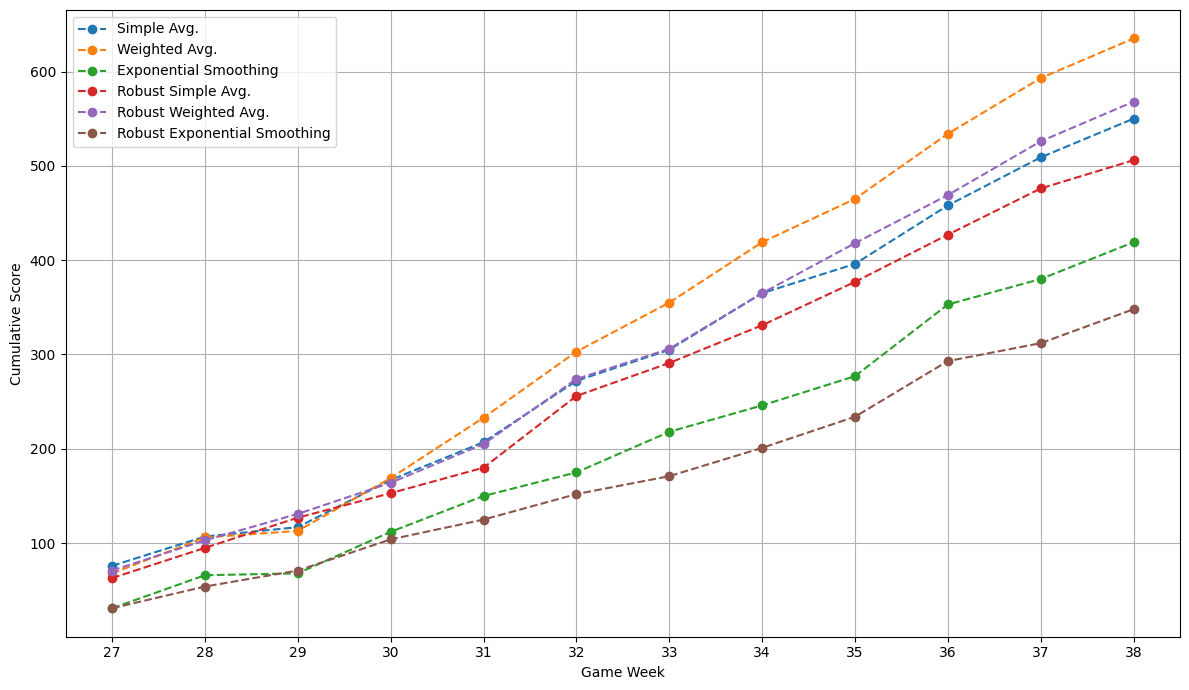

Saved: 02_simple_vs_simulations.pdf


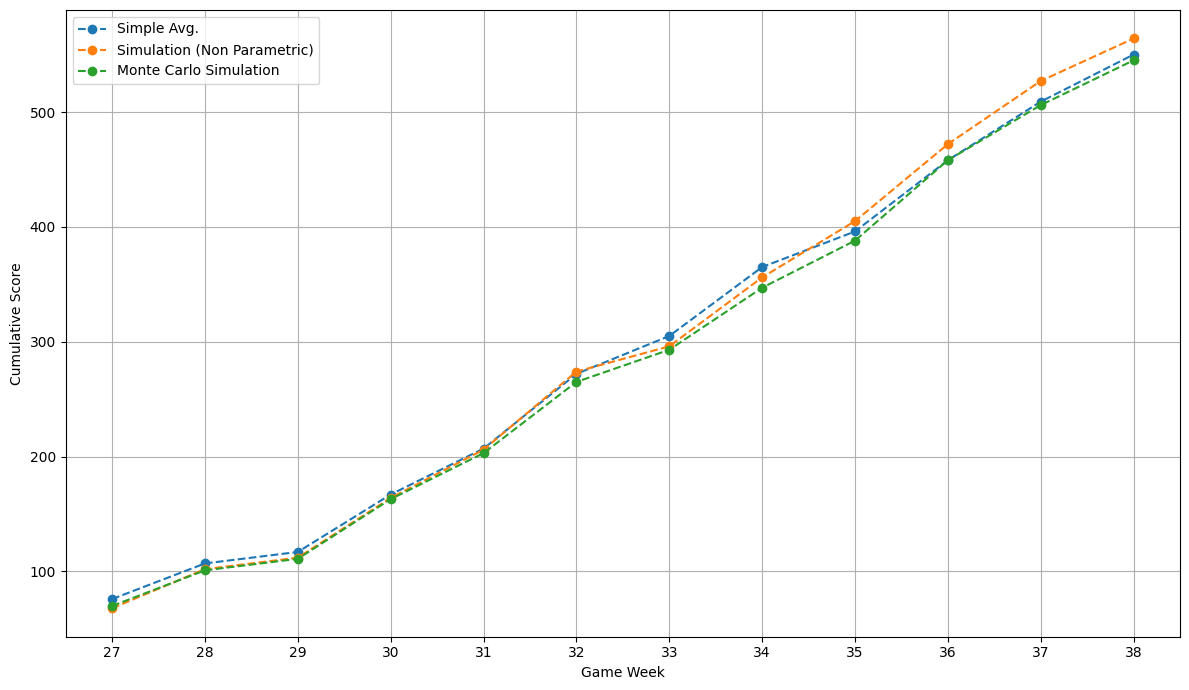

Saved: 03_arima_variants.pdf


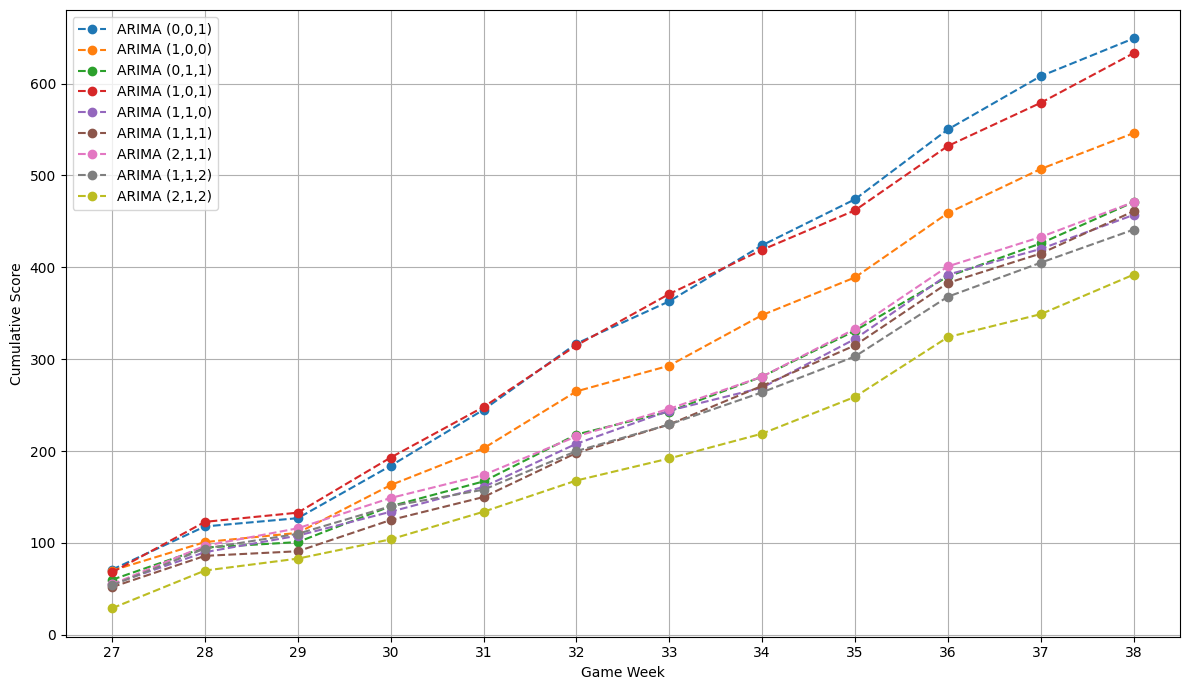

Saved: 04_ict_involvement.pdf


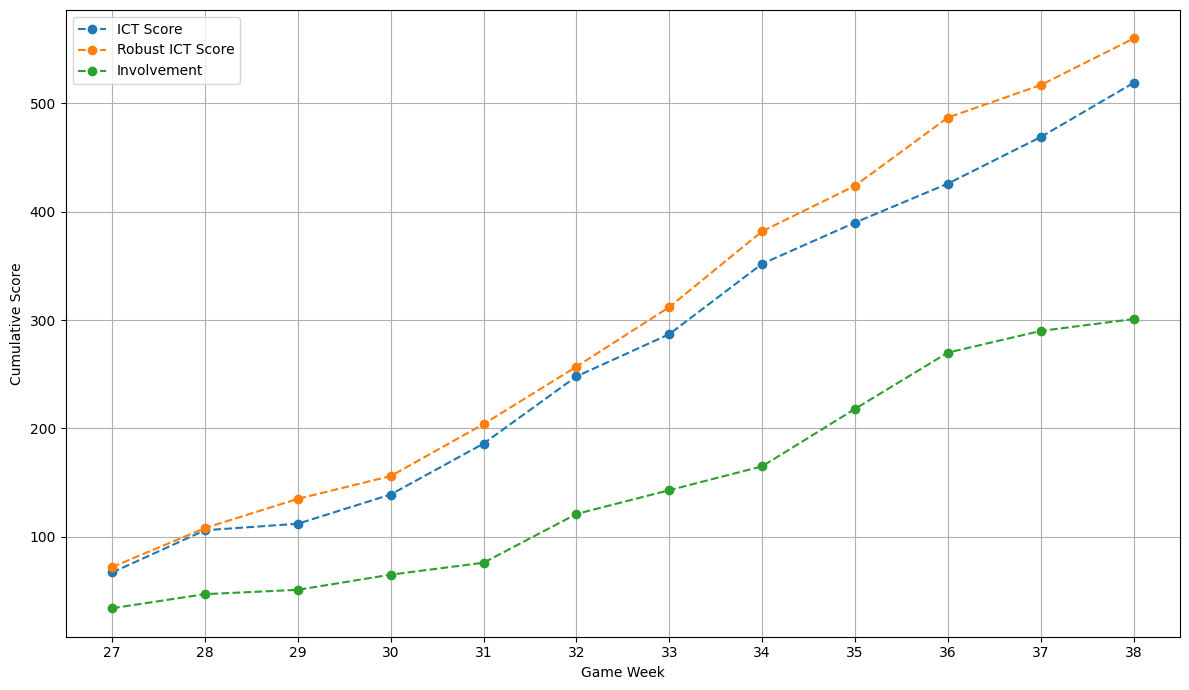

Saved: 05_simple_weighted_exponential_hybrids.pdf


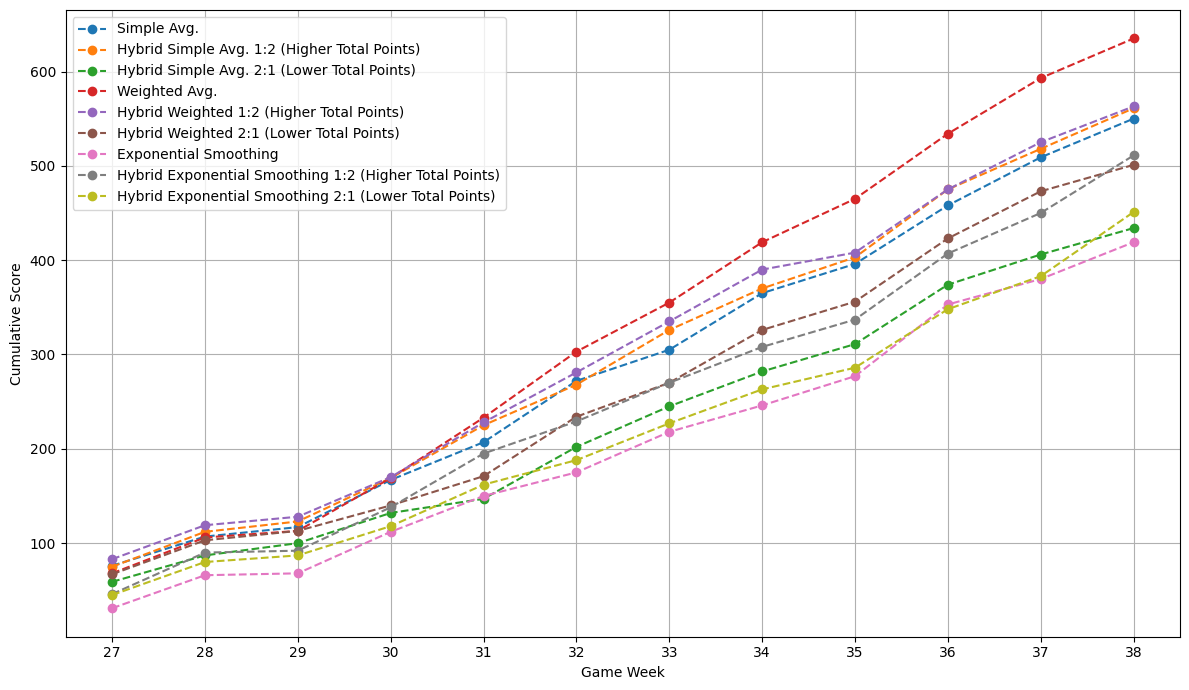

Saved: 06_simulation_and_mc_hybrids.pdf


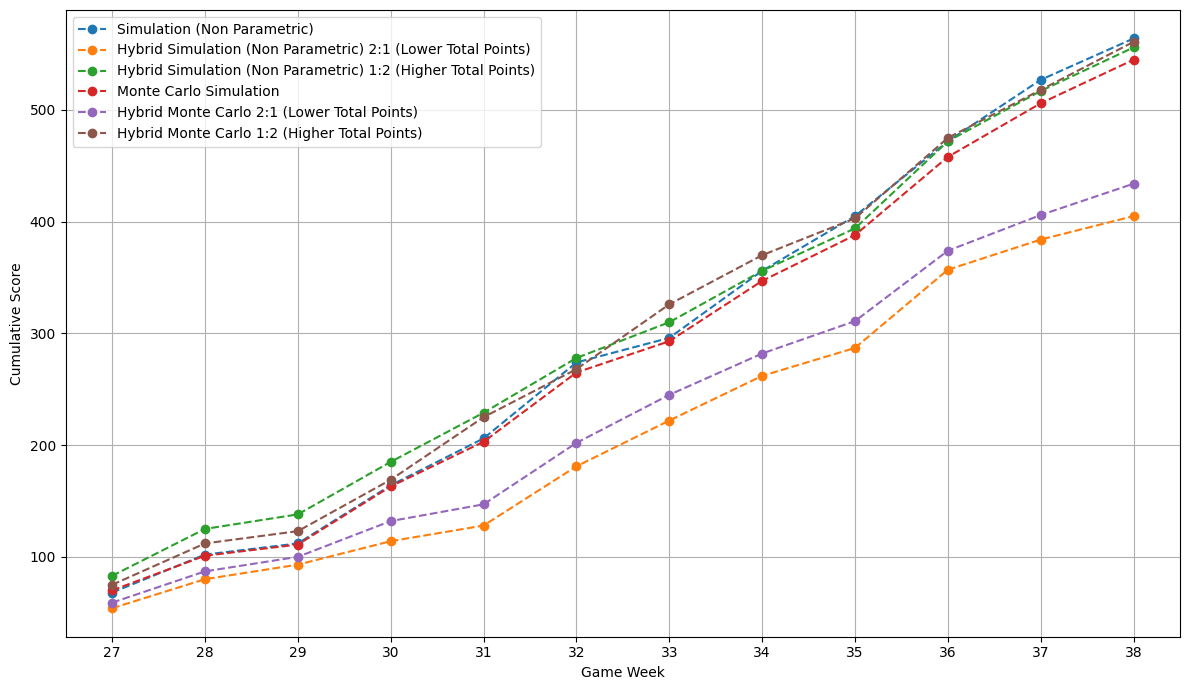

Saved: 07_arima_hybrid_arima.pdf


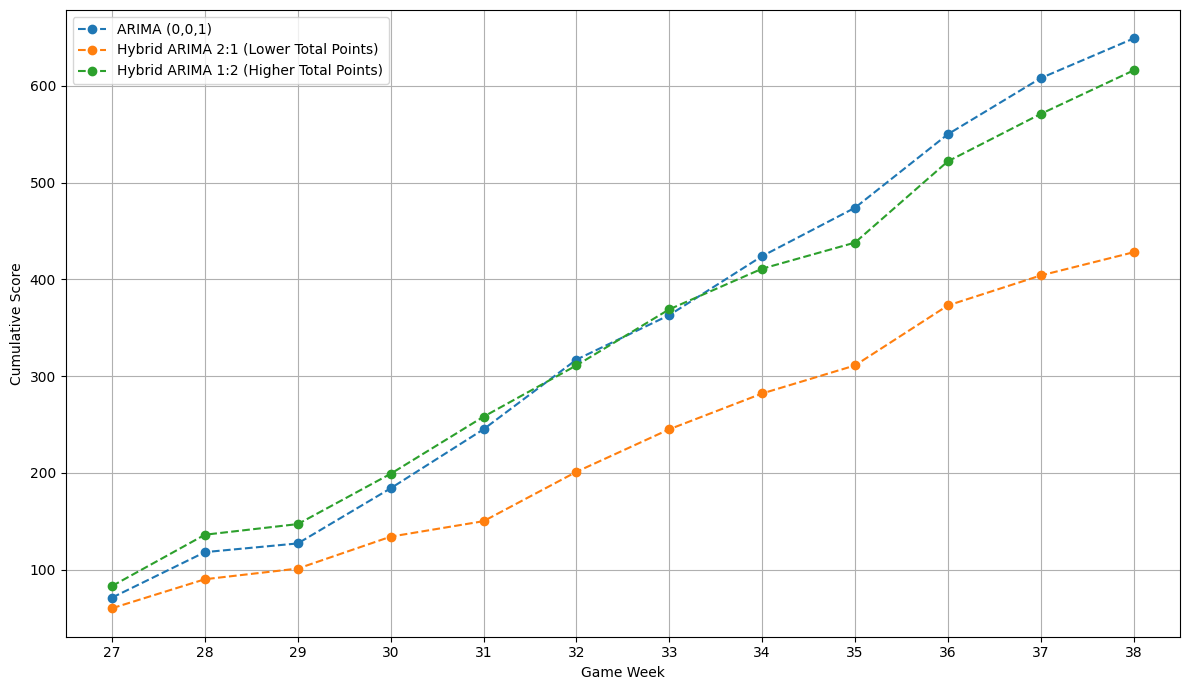

Saved: 08_ict_hybrid_lr.pdf


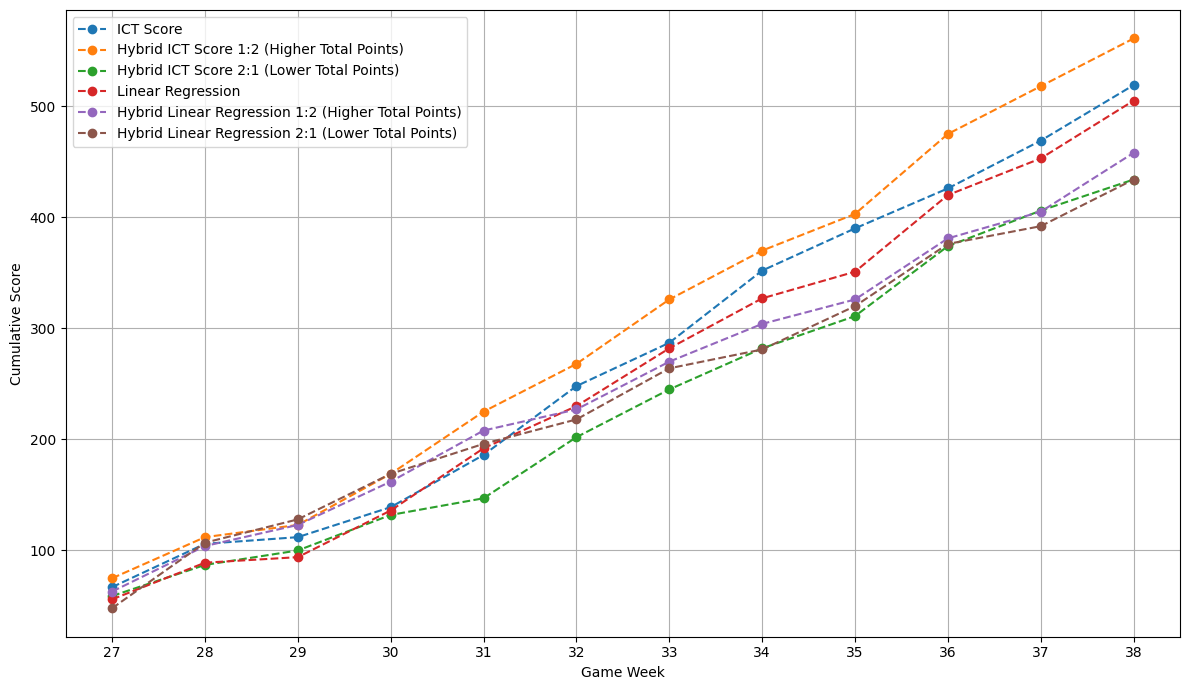

Saved: 09_simple_budgets.pdf


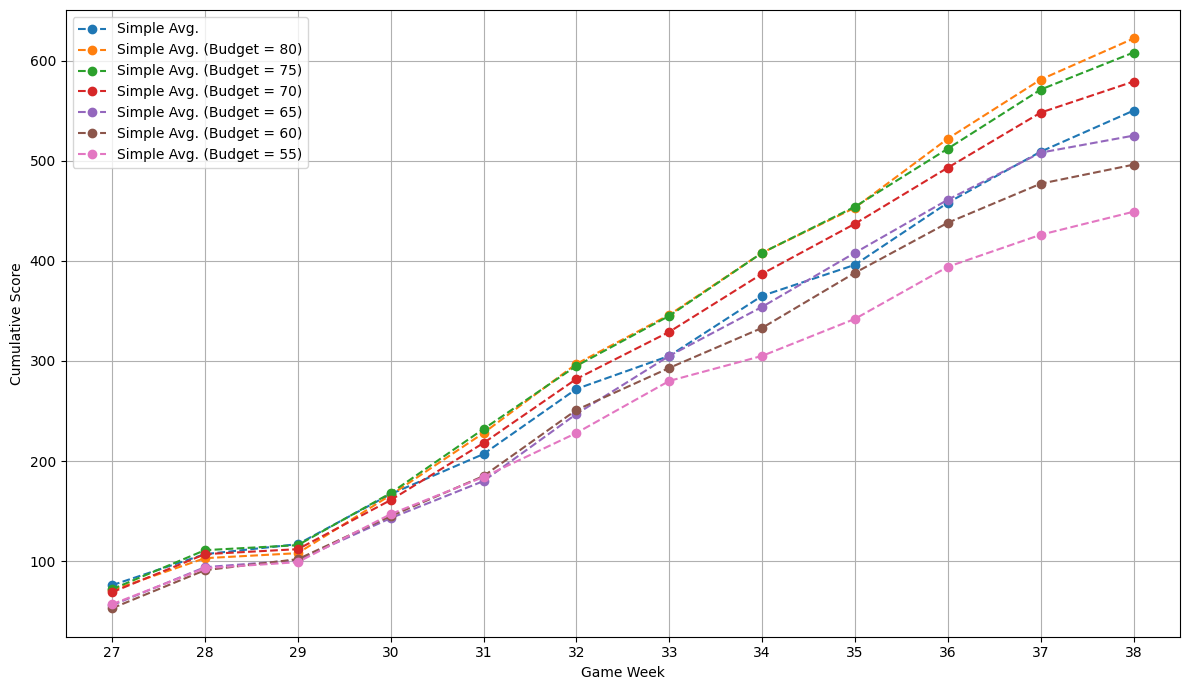

Saved: 10_weighted_budgets.pdf


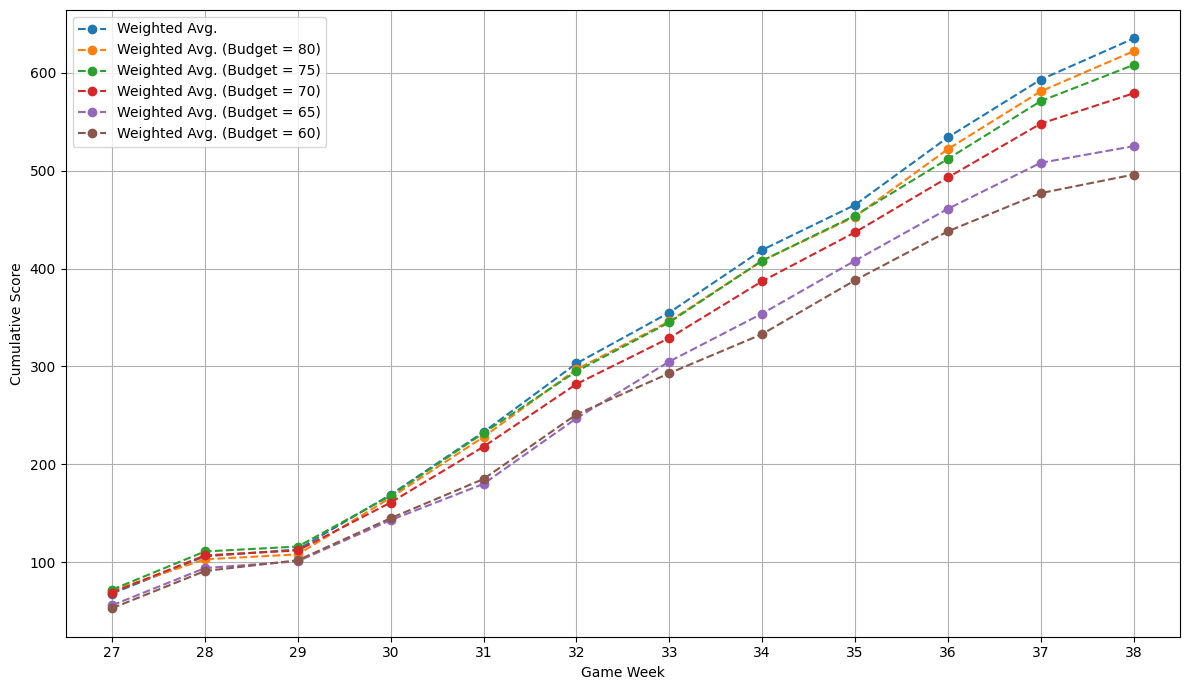

Saved: 11_arima_001_budgets.pdf


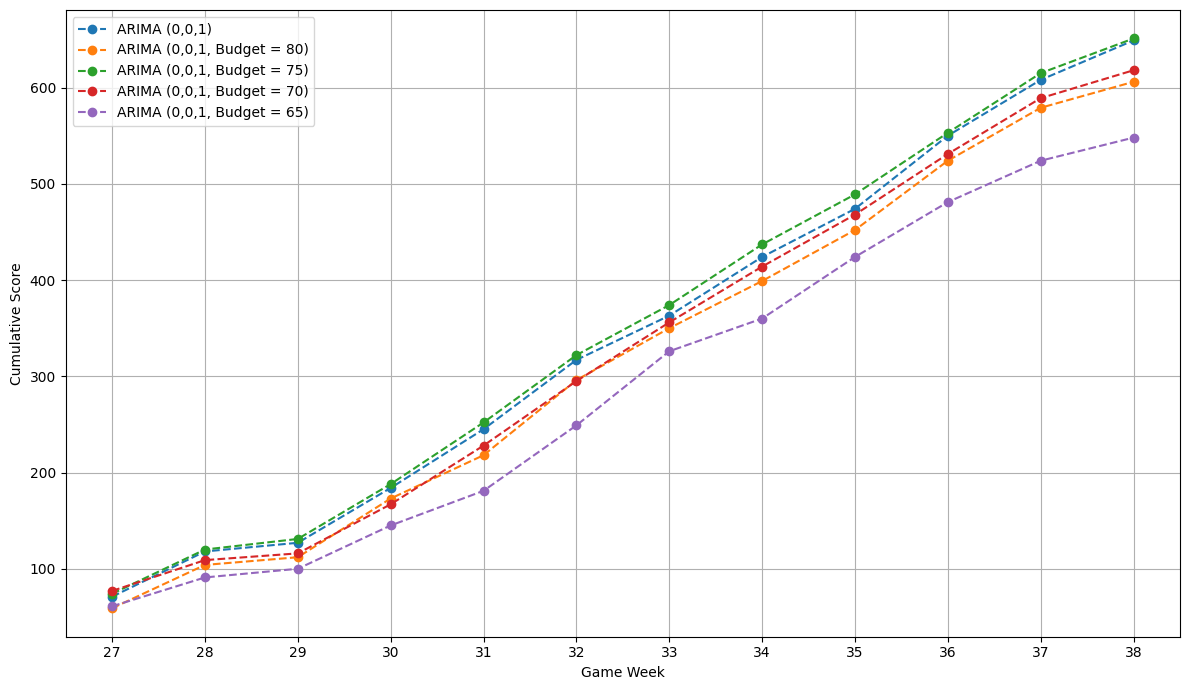

Saved: 12_arima_100_budgets.pdf


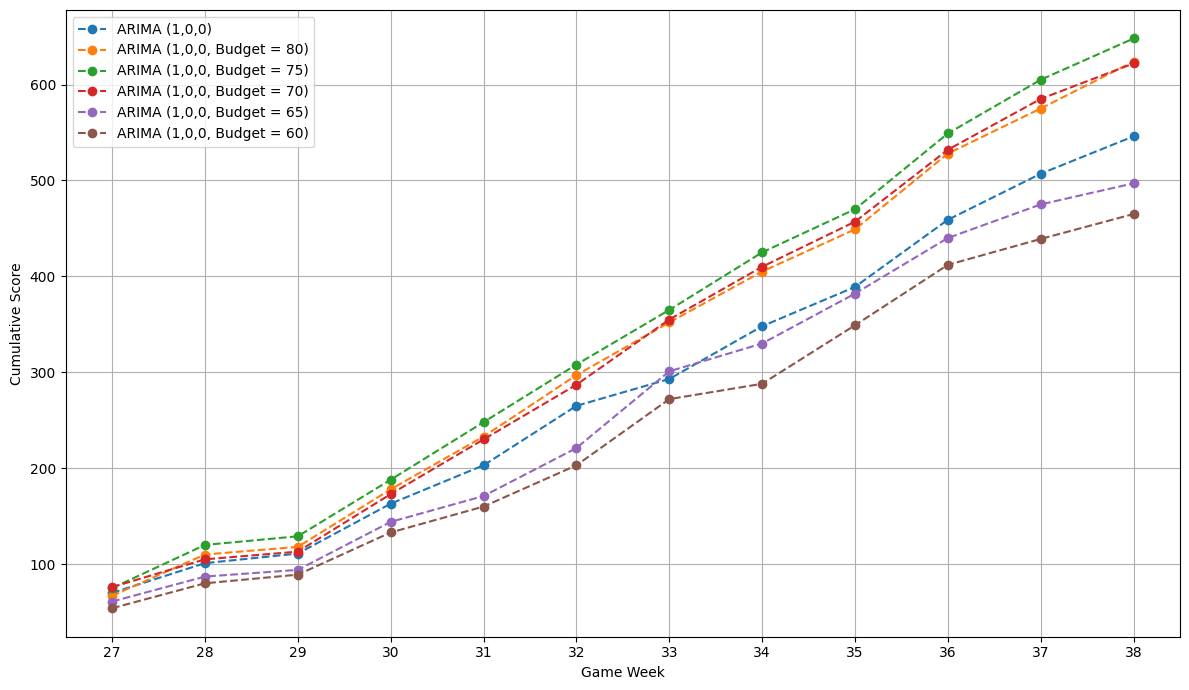

Saved: 13_arima_101_budgets.pdf


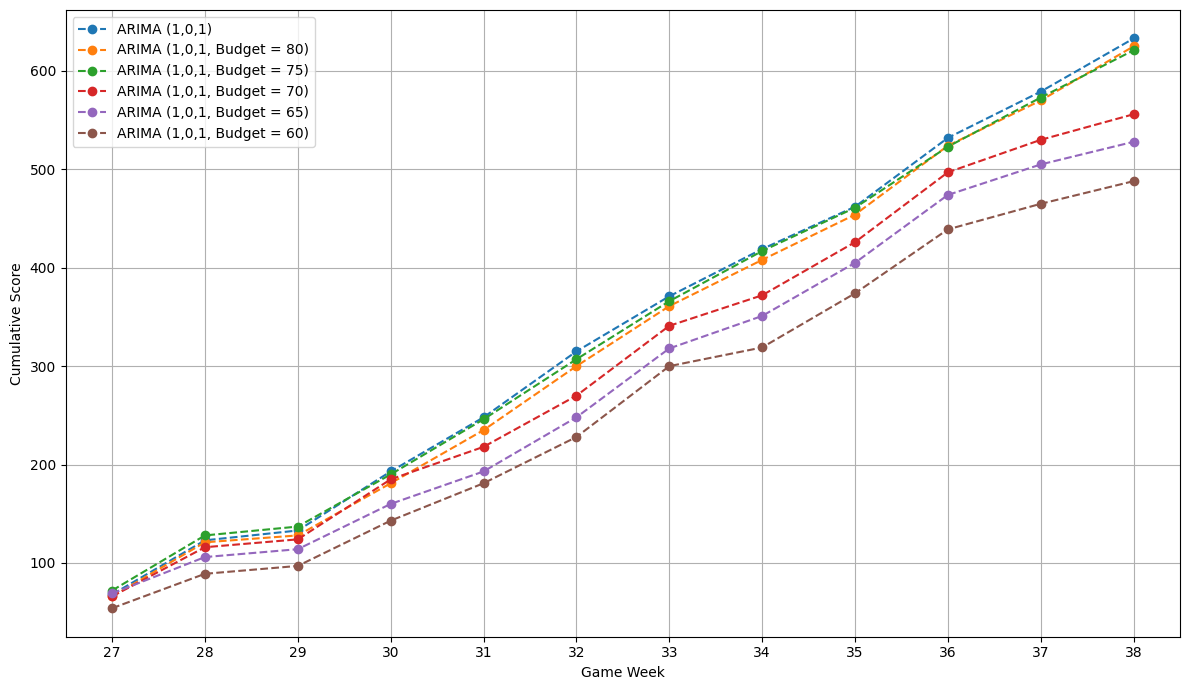

Saved: 14_ict_budgets.pdf


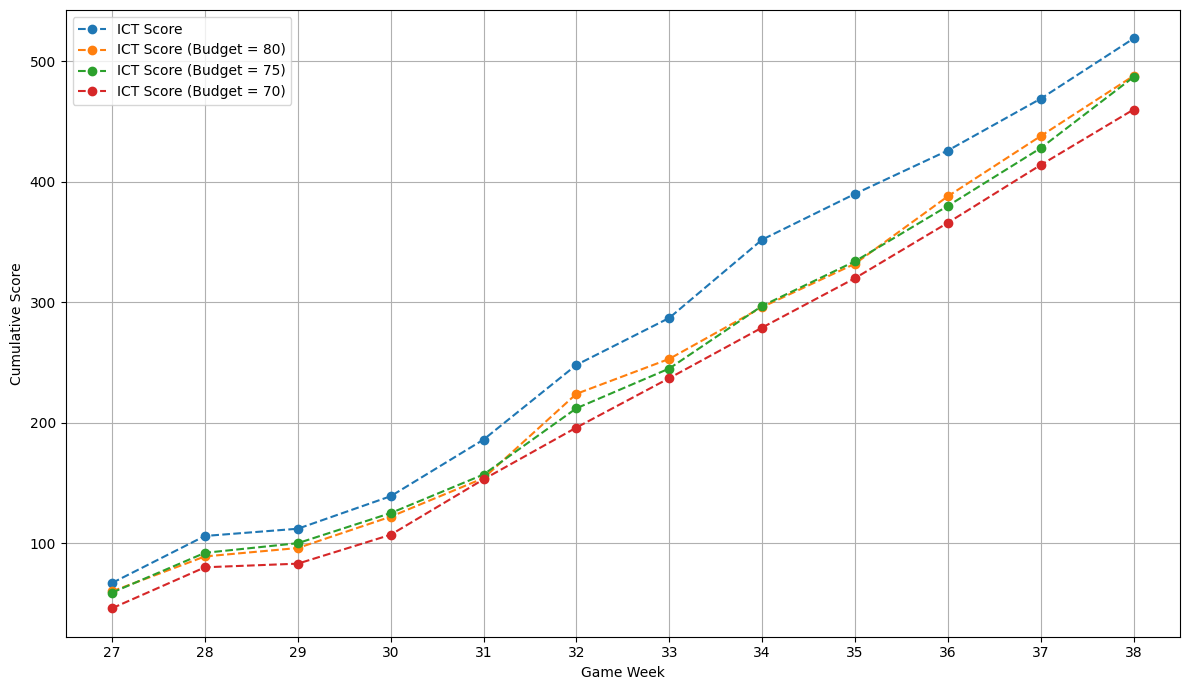

Saved: 15_hybrid_ict_budgets.pdf


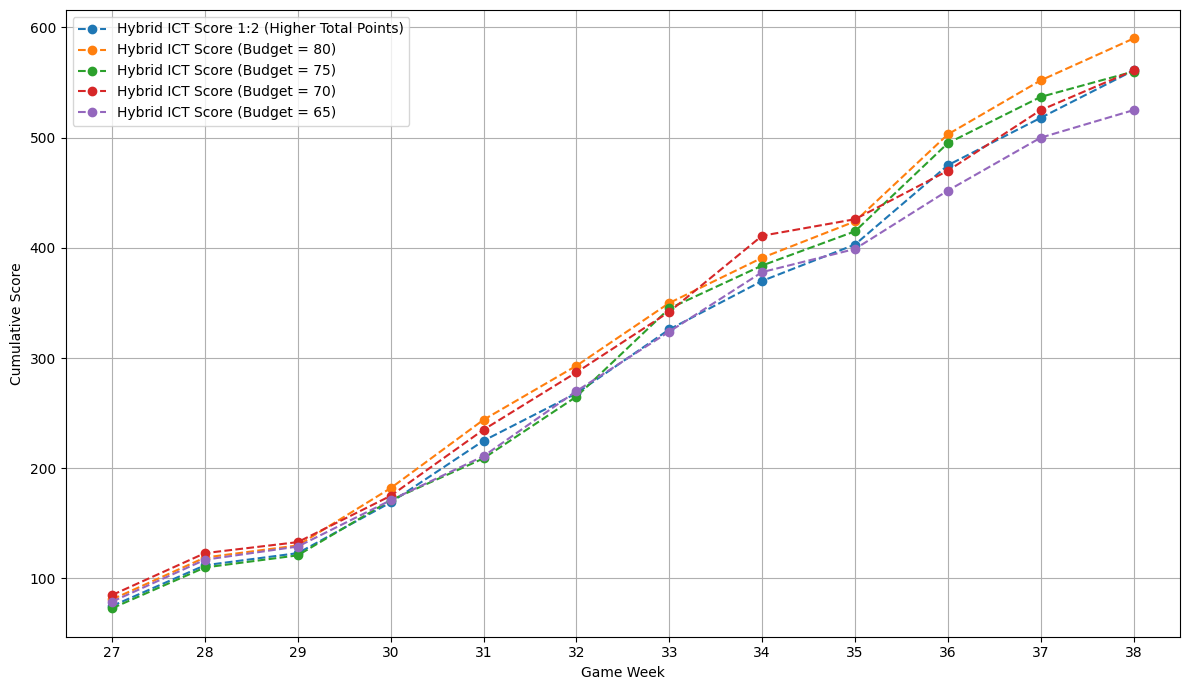

Saved: 16_monte_carlo_budgets.pdf


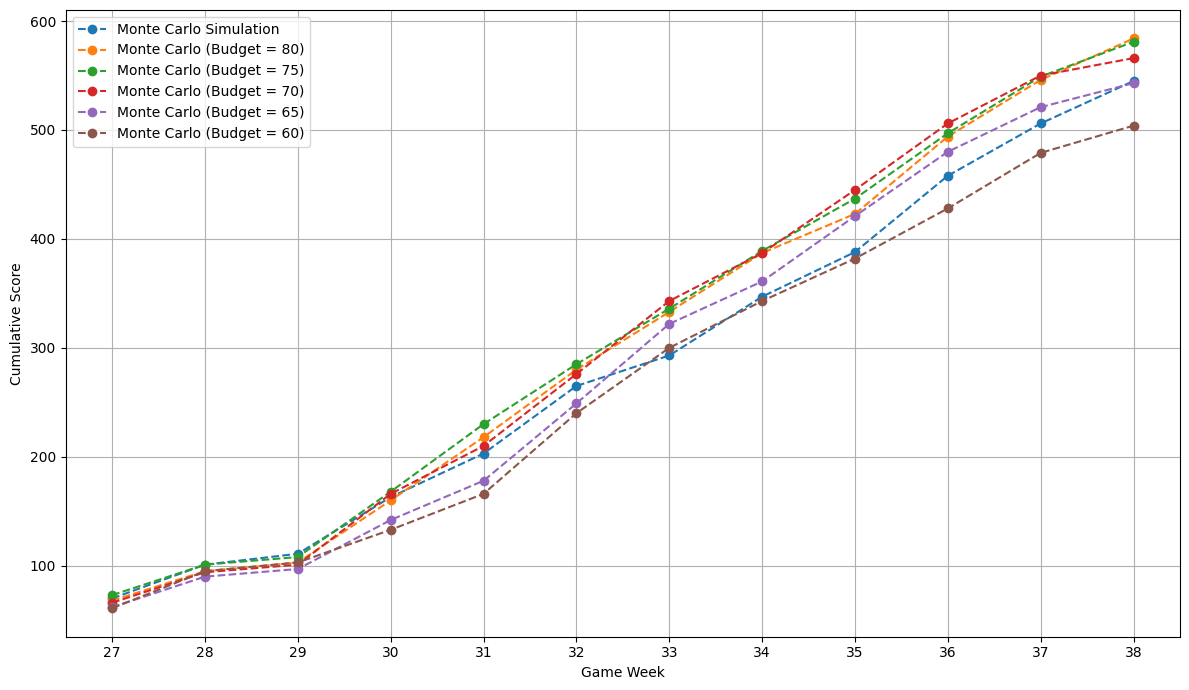

Saved: 17_arima_100_rolling_set.pdf


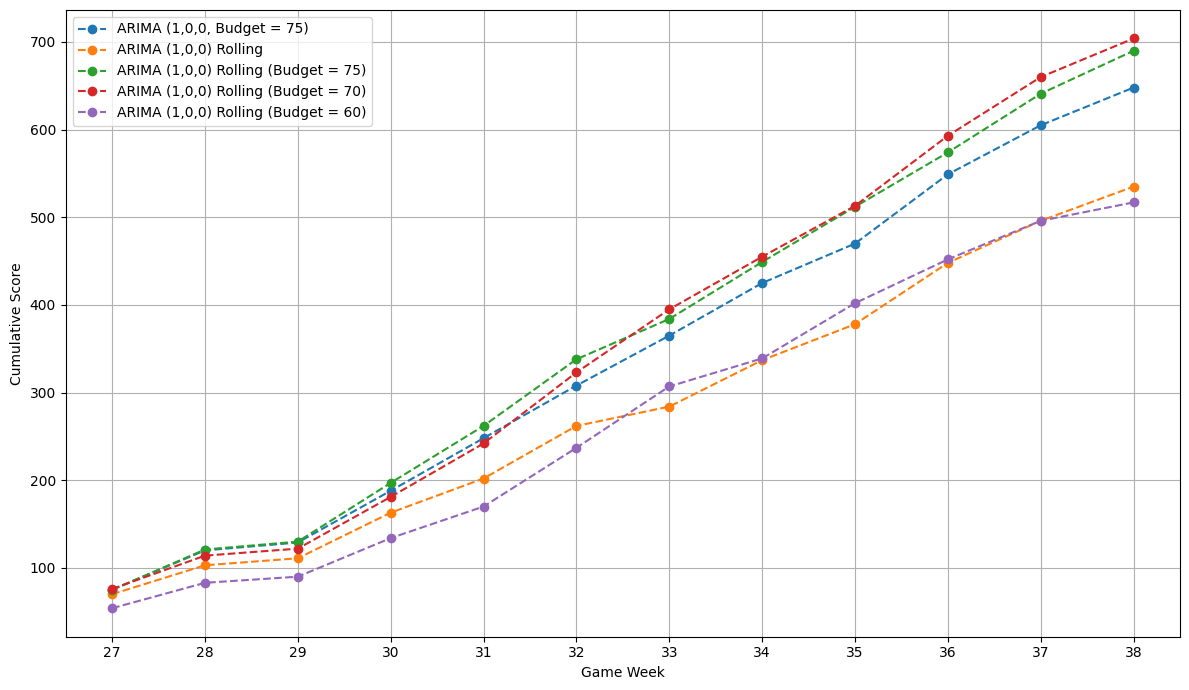

Saved: 18_arima_101_rolling_set.pdf


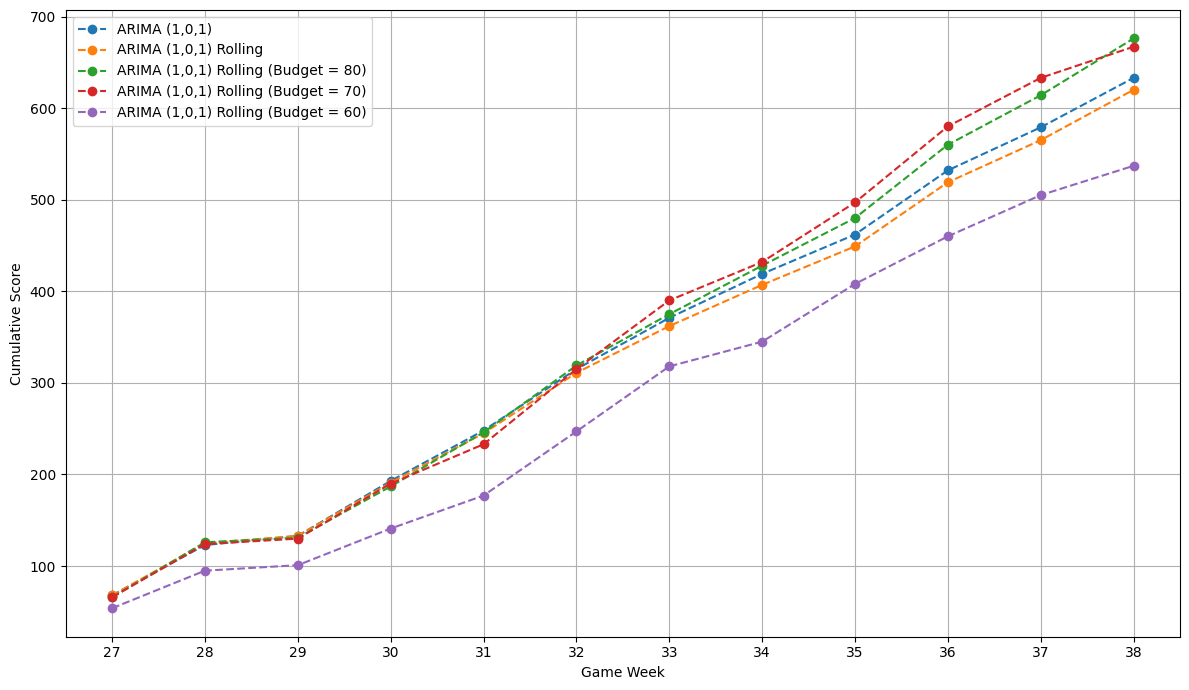

Saved: 19_simple_rolling_set.pdf


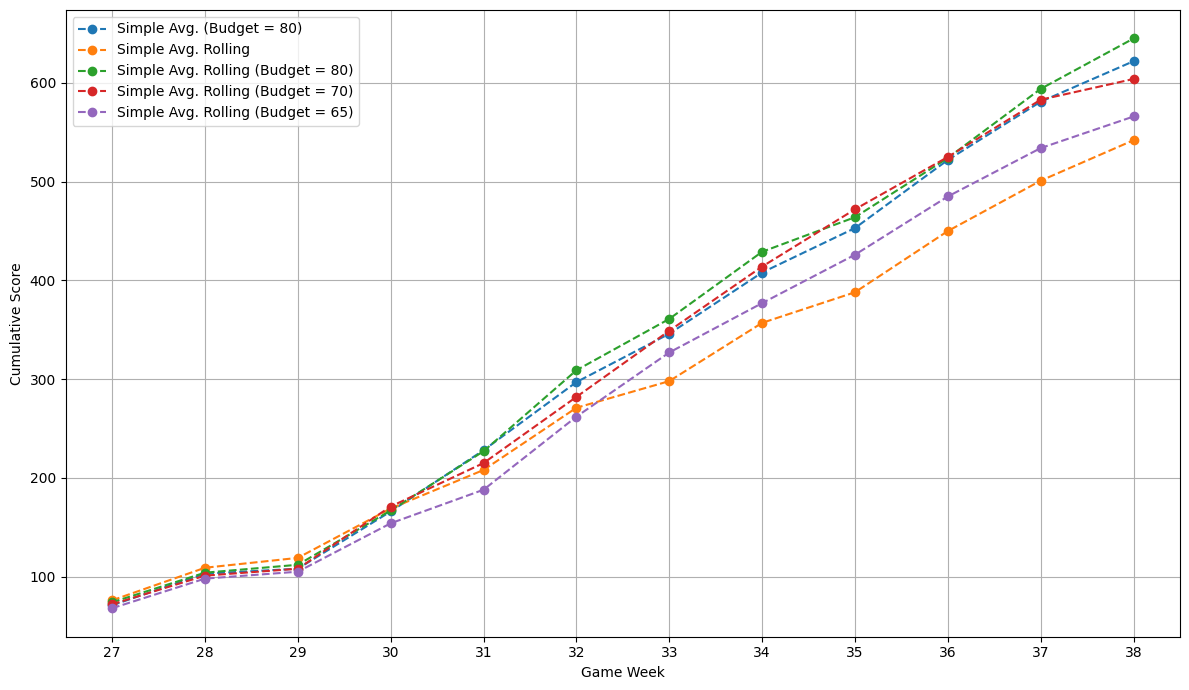

Saved: 20_weighted_rolling_set.pdf


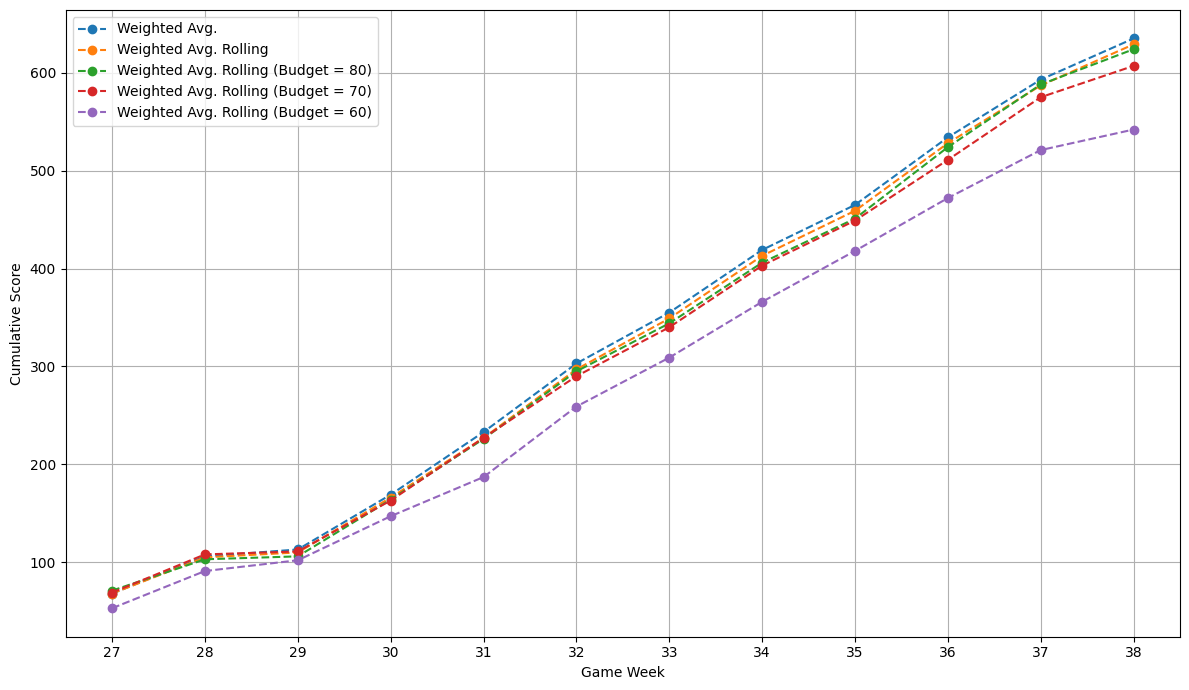

Saved: 21_arima_001_rolling_set.pdf


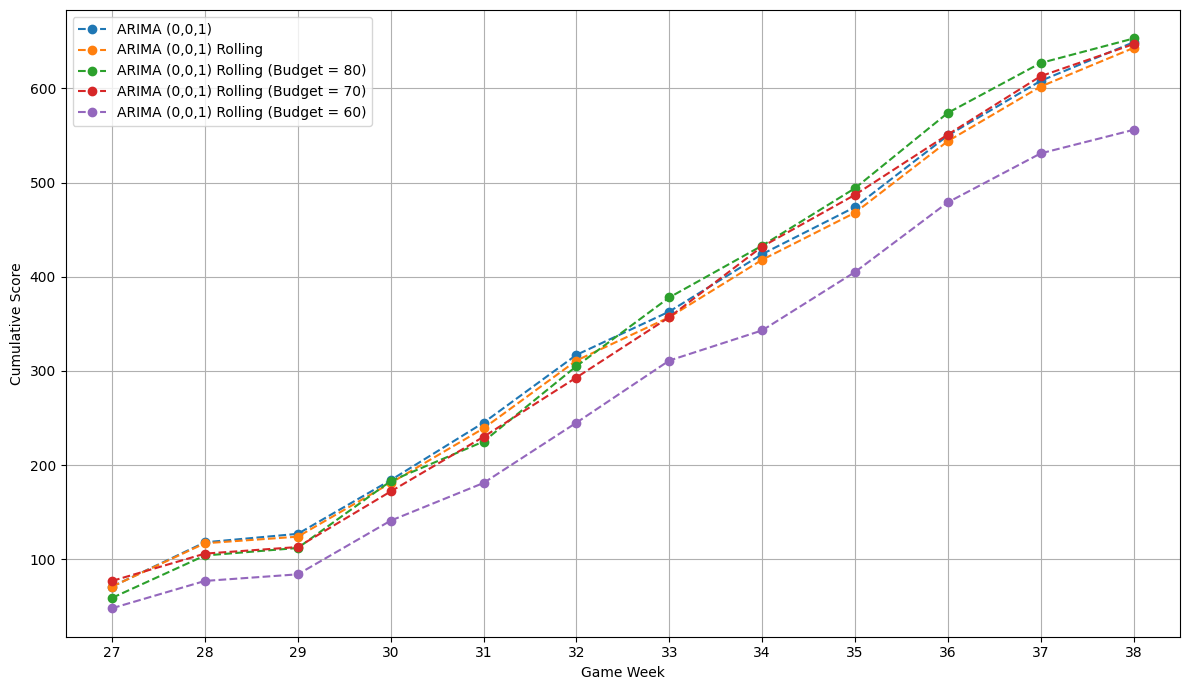

Saved: 22_quick_comparison.pdf


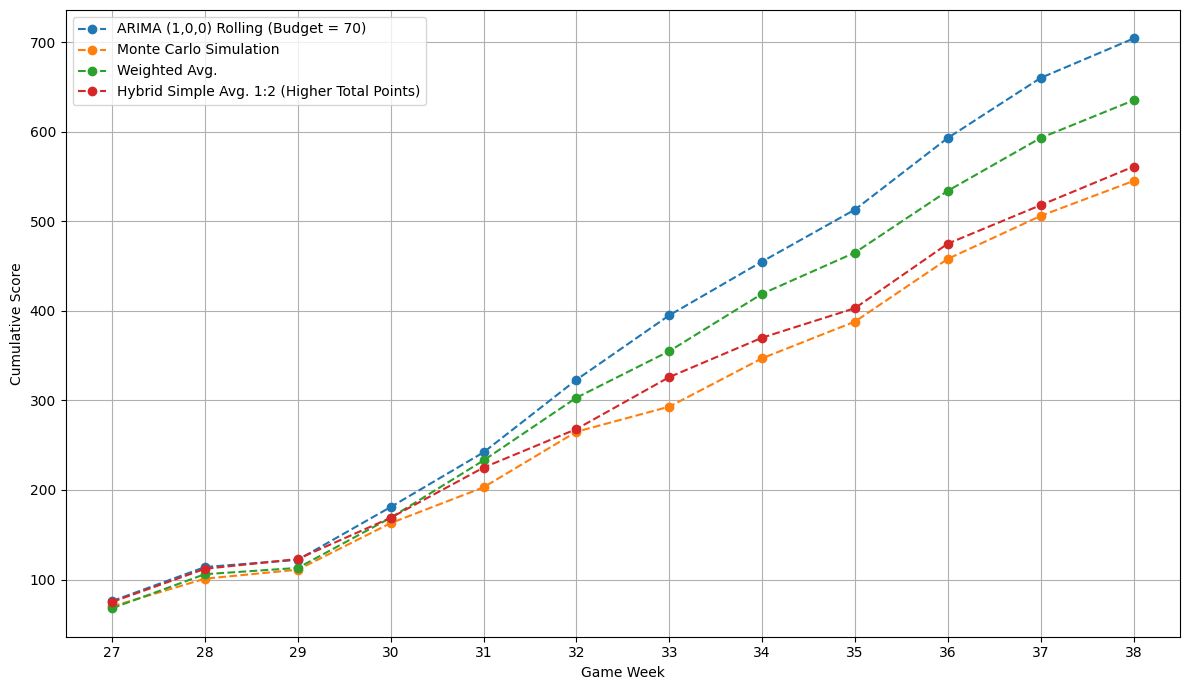

Saved: 23_arima_vs_santoro.pdf


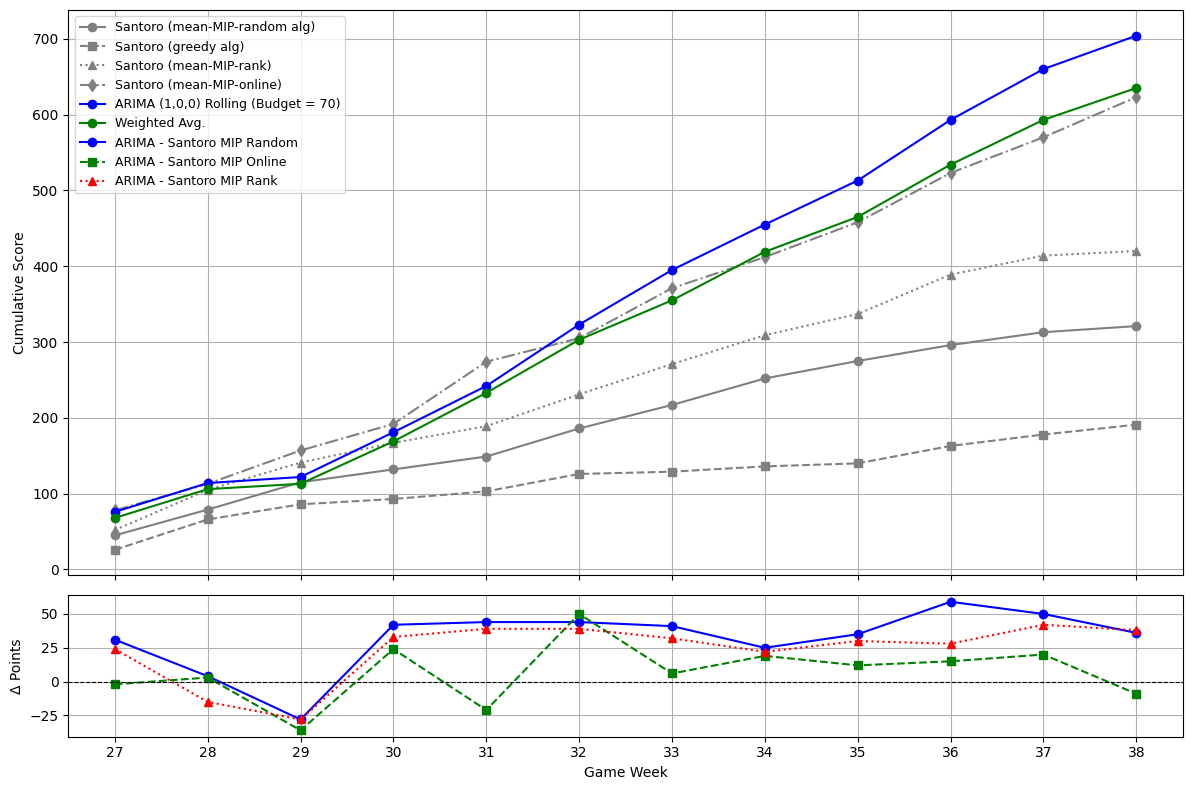

In [6]:
# --- Compact visualization suite (PDF @300dpi and x-ticks start at 27) ---
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load Results.csv if not already present
try:
    res  # noqa: F821
except NameError:
    res = pd.read_csv("Results.csv")

Sdf = res  # keep your original name
GW_START = 27
gameweeks = list(range(GW_START, GW_START + len(Sdf)))

# ----------------- helpers -----------------
def _ensure_cols(df, cols):
    """Raise if any requested label is missing in df.columns."""
    missing = [c for c in cols if c not in set(df.columns)]
    if missing:
        raise KeyError(f"Missing columns in Results.csv: {missing}")

def _series_first(df, name):
    """
    Return the FIRST occurrence of the column named `name` as a 1D Series.
    Handles duplicate column labels (df may contain multiple columns with same name).
    """
    mask = (df.columns == name)
    if not mask.any():
        raise KeyError(f"Column not found: {name}")
    col = df.loc[:, mask]
    if isinstance(col, pd.DataFrame):
        s = col.iloc[:, 0]
    else:
        s = col
    return pd.Series(s.to_numpy(), name=name, index=df.index)

def _frame_first(df, cols):
    """Build a DataFrame with unique column names using the first occurrence for each label."""
    return pd.DataFrame({c: _series_first(df, c).to_numpy() for c in cols})

# ---------- figure saving (PDF @ 300 dpi) ----------
_PLOT_COUNTER = 1

def _slugify(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"\s+", "_", name)
    name = re.sub(r"[^\w\-\.]", "", name)
    return name

def _save_current_fig(save_name: str | None = None):
    """Save current matplotlib figure as PDF (300 dpi), auto-numbered if no name given."""
    global _PLOT_COUNTER
    if save_name:
        fname = _slugify(save_name)
        if not fname.endswith(".pdf"):
            fname += ".pdf"
    else:
        fname = f"plot_{_PLOT_COUNTER:02d}.pdf"
    plt.savefig(fname, format="pdf", dpi=300, bbox_inches="tight")
    print(f"Saved: {fname}")
    _PLOT_COUNTER += 1

def _apply_x_ticks(ax, pad=0.5):
    """
    Force x-axis ticks to start at 27 and add symmetric padding on both
    sides so the first/last markers aren't flush against the frame.

    pad = 0.5 shows half a GW of space on each side; tweak if you want more/less.
    """
    left  = gameweeks[0] - pad
    right = gameweeks[-1] + pad
    ax.set_xlim(left, right)
    ax.set_xticks(gameweeks)
    ax.margins(x=0)  # keep our explicit padding; don't add extra automatic margins


# ----------------- plotting APIs -----------------
def plot_cumulative(cols, marker="o", linestyle="--", save_name=None):
    """
    Single-panel cumulative plots:
    - cumulative sum over specified columns
    - same marker ('o') and linestyle ('--')
    """
    _ensure_cols(Sdf, cols)
    cumulative = _frame_first(Sdf, cols).cumsum()

    plt.figure(figsize=(12, 7))
    for col in cols:
        plt.plot(gameweeks, cumulative[col], marker=marker, linestyle=linestyle, label=col)

    plt.xlabel("Game Week")
    plt.ylabel("Cumulative Score")
    plt.legend()
    plt.grid(True)
    _apply_x_ticks(plt.gca())
    plt.tight_layout()
    _save_current_fig(save_name)
    plt.show()
    plt.close()

def plot_main_and_diff_arima_vs_santoro(save_name="arima_vs_santoro.pdf"):
    """
    Final two-panel figure (main cumulative + differences).
    """
    cols_main = [
        "ARIMA (1,0,0) Rolling (Budget = 70)",
        "Weighted Avg."
    ]
    santoro_cols = [
        "Santoro (mean-MIP-random alg)",
        "Santoro (greedy alg)",
        "Santoro (mean-MIP-rank)",
        "Santoro (mean-MIP-online)"
    ]
    _ensure_cols(Sdf, cols_main + santoro_cols)

    cumulative = _frame_first(Sdf, cols_main + santoro_cols).cumsum()

    fig, (ax_main, ax_diff) = plt.subplots(
        2, 1, figsize=(12, 8),
        gridspec_kw={"height_ratios": [4, 1]},
        sharex=True
    )

    # Gray benchmark styles
    benchmark_styles = {
        "Santoro (mean-MIP-random alg)": ("-", "o"),
        "Santoro (greedy alg)": ("--", "s"),
        "Santoro (mean-MIP-rank)": (":", "^"),
        "Santoro (mean-MIP-online)": ("-.", "d")
    }
    for col, (linestyle, marker) in benchmark_styles.items():
        ax_main.plot(gameweeks, cumulative[col], linestyle=linestyle, marker=marker,
                     color="gray", label=col)

    # Overlay ARIMA + Weighted
    ax_main.plot(
        gameweeks, cumulative["ARIMA (1,0,0) Rolling (Budget = 70)"],
        marker="o", linestyle="-", color="blue",
        label="ARIMA (1,0,0) Rolling (Budget = 70)"
    )
    ax_main.plot(
        gameweeks, cumulative["Weighted Avg."],
        marker="o", linestyle="-", color="green", label="Weighted Avg."
    )

    ax_main.set_ylabel("Cumulative Score")
    ax_main.grid(True)

    # Differences (element-wise)
    arima_vals = _series_first(Sdf, "ARIMA (1,0,0) Rolling (Budget = 70)").to_numpy()
    diff_random = arima_vals - _series_first(Sdf, "Santoro (mean-MIP-random alg)").to_numpy()
    diff_online = arima_vals - _series_first(Sdf, "Santoro (mean-MIP-online)").to_numpy()
    diff_rank   = arima_vals - _series_first(Sdf, "Santoro (mean-MIP-rank)").to_numpy()

    ax_diff.plot(gameweeks, diff_random, marker="o", linestyle="-", color="blue",
                 label="ARIMA - Santoro MIP Random")
    ax_diff.plot(gameweeks, diff_online, marker="s", linestyle="--", color="green",
                 label="ARIMA - Santoro MIP Online")
    ax_diff.plot(gameweeks, diff_rank, marker="^", linestyle=":", color="red",
                 label="ARIMA - Santoro MIP Rank")

    ax_diff.axhline(0, color="black", linewidth=0.8, linestyle="--", label="_nolegend_")
    ax_diff.set_xlabel("Game Week")
    ax_diff.set_ylabel("Δ Points")
    ax_diff.grid(True)

    # Force ticks to start at 27 on both axes
    _apply_x_ticks(ax_main)
    _apply_x_ticks(ax_diff)

    # Merge legends
    h1, l1 = ax_main.get_legend_handles_labels()
    h2, l2 = ax_diff.get_legend_handles_labels()
    ax_main.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

    plt.tight_layout()
    _save_current_fig(save_name)
    plt.show()
    plt.close()

# -------------------------
# Plot groups (exact series & order you provided)
# -------------------------

# 1) Simple/Weighted/Exponential + Robusts
plot_cumulative([
    "Simple Avg.", "Weighted Avg.", "Exponential Smoothing",
    "Robust Simple Avg.", "Robust Weighted Avg.", "Robust Exponential Smoothing"
], save_name="01_simple_weighted_exponential_and_robusts.pdf")

# 2) Simple vs Simulations
plot_cumulative([
    "Simple Avg.", "Simulation (Non Parametric)", "Monte Carlo Simulation"
], save_name="02_simple_vs_simulations.pdf")

# 3) ARIMA variants
plot_cumulative([
    "ARIMA (0,0,1)", "ARIMA (1,0,0)", "ARIMA (0,1,1)",
    "ARIMA (1,0,1)", "ARIMA (1,1,0)", "ARIMA (1,1,1)",
    "ARIMA (2,1,1)", "ARIMA (1,1,2)", "ARIMA (2,1,2)"
], save_name="03_arima_variants.pdf")

# 4) ICT & Involvement
plot_cumulative(["ICT Score", "Robust ICT Score", "Involvement"],
                save_name="04_ict_involvement.pdf")

# 5) Simple/Weighted/Exponential + Hybrid variants
plot_cumulative([
    "Simple Avg.",
    "Hybrid Simple Avg. 1:2 (Higher Total Points)",
    "Hybrid Simple Avg. 2:1 (Lower Total Points)",
    "Weighted Avg.",
    "Hybrid Weighted 1:2 (Higher Total Points)",
    "Hybrid Weighted 2:1 (Lower Total Points)",
    "Exponential Smoothing",
    "Hybrid Exponential Smoothing 1:2 (Higher Total Points)",
    "Hybrid Exponential Smoothing 2:1 (Lower Total Points)"
], save_name="05_simple_weighted_exponential_hybrids.pdf")

# 6) Simulation + Hybrid Sim + MC + Hybrid MC
plot_cumulative([
    "Simulation (Non Parametric)",
    "Hybrid Simulation (Non Parametric) 2:1 (Lower Total Points)",
    "Hybrid Simulation (Non Parametric) 1:2 (Higher Total Points)",
    "Monte Carlo Simulation",
    "Hybrid Monte Carlo 2:1 (Lower Total Points)",
    "Hybrid Monte Carlo 1:2 (Higher Total Points)"
], save_name="06_simulation_and_mc_hybrids.pdf")

# 7) ARIMA + Hybrid ARIMA
plot_cumulative([
    "ARIMA (0,0,1)",
    "Hybrid ARIMA 2:1 (Lower Total Points)",
    "Hybrid ARIMA 1:2 (Higher Total Points)"
], save_name="07_arima_hybrid_arima.pdf")

# 8) ICT + Hybrid ICT + Linear Regression + Hybrid LR
plot_cumulative([
    "ICT Score",
    "Hybrid ICT Score 1:2 (Higher Total Points)",
    "Hybrid ICT Score 2:1 (Lower Total Points)",
    "Linear Regression",
    "Hybrid Linear Regression 1:2 (Higher Total Points)",
    "Hybrid Linear Regression 2:1 (Lower Total Points)"
], save_name="08_ict_hybrid_lr.pdf")

# 9) Simple budgets
plot_cumulative([
    "Simple Avg.",
    "Simple Avg. (Budget = 80)",
    "Simple Avg. (Budget = 75)",
    "Simple Avg. (Budget = 70)",
    "Simple Avg. (Budget = 65)",
    "Simple Avg. (Budget = 60)",
    "Simple Avg. (Budget = 55)"
], save_name="09_simple_budgets.pdf")

# 10) Weighted budgets
plot_cumulative([
    "Weighted Avg.",
    "Weighted Avg. (Budget = 80)",
    "Weighted Avg. (Budget = 75)",
    "Weighted Avg. (Budget = 70)",
    "Weighted Avg. (Budget = 65)",
    "Weighted Avg. (Budget = 60)"
], save_name="10_weighted_budgets.pdf")

# 11) ARIMA (0,0,1) budgets
plot_cumulative([
    "ARIMA (0,0,1)",
    "ARIMA (0,0,1, Budget = 80)",
    "ARIMA (0,0,1, Budget = 75)",
    "ARIMA (0,0,1, Budget = 70)",
    "ARIMA (0,0,1, Budget = 65)"
], save_name="11_arima_001_budgets.pdf")

# 12) ARIMA (1,0,0) budgets
plot_cumulative([
    "ARIMA (1,0,0)",
    "ARIMA (1,0,0, Budget = 80)",
    "ARIMA (1,0,0, Budget = 75)",
    "ARIMA (1,0,0, Budget = 70)",
    "ARIMA (1,0,0, Budget = 65)",
    "ARIMA (1,0,0, Budget = 60)"
], save_name="12_arima_100_budgets.pdf")

# 13) ARIMA (1,0,1) budgets
plot_cumulative([
    "ARIMA (1,0,1)",
    "ARIMA (1,0,1, Budget = 80)",
    "ARIMA (1,0,1, Budget = 75)",
    "ARIMA (1,0,1, Budget = 70)",
    "ARIMA (1,0,1, Budget = 65)",
    "ARIMA (1,0,1, Budget = 60)"
], save_name="13_arima_101_budgets.pdf")

# 14) ICT budgets
plot_cumulative([
    "ICT Score",
    "ICT Score (Budget = 80)",
    "ICT Score (Budget = 75)",
    "ICT Score (Budget = 70)"
], save_name="14_ict_budgets.pdf")

# 15) Hybrid ICT budgets
plot_cumulative([
    "Hybrid ICT Score 1:2 (Higher Total Points)",
    "Hybrid ICT Score (Budget = 80)",
    "Hybrid ICT Score (Budget = 75)",
    "Hybrid ICT Score (Budget = 70)",
    "Hybrid ICT Score (Budget = 65)"
], save_name="15_hybrid_ict_budgets.pdf")

# 16) Monte Carlo budgets
plot_cumulative([
    "Monte Carlo Simulation",
    "Monte Carlo (Budget = 80)",
    "Monte Carlo (Budget = 75)",
    "Monte Carlo (Budget = 70)",
    "Monte Carlo (Budget = 65)",
    "Monte Carlo (Budget = 60)"
], save_name="16_monte_carlo_budgets.pdf")

# 17) ARIMA (1,0,0) Rolling set
plot_cumulative([
    "ARIMA (1,0,0, Budget = 75)",
    "ARIMA (1,0,0) Rolling",
    "ARIMA (1,0,0) Rolling (Budget = 75)",
    "ARIMA (1,0,0) Rolling (Budget = 70)",
    "ARIMA (1,0,0) Rolling (Budget = 60)"
], save_name="17_arima_100_rolling_set.pdf")

# 18) ARIMA (1,0,1) Rolling set
plot_cumulative([
    "ARIMA (1,0,1)",
    "ARIMA (1,0,1) Rolling",
    "ARIMA (1,0,1) Rolling (Budget = 80)",
    "ARIMA (1,0,1) Rolling (Budget = 70)",
    "ARIMA (1,0,1) Rolling (Budget = 60)"
], save_name="18_arima_101_rolling_set.pdf")

# 19) Simple Rolling set
plot_cumulative([
    "Simple Avg. (Budget = 80)",
    "Simple Avg. Rolling",
    "Simple Avg. Rolling (Budget = 80)",
    "Simple Avg. Rolling (Budget = 70)",
    "Simple Avg. Rolling (Budget = 65)"
], save_name="19_simple_rolling_set.pdf")

# 20) Weighted Rolling set
plot_cumulative([
    "Weighted Avg.",
    "Weighted Avg. Rolling",
    "Weighted Avg. Rolling (Budget = 80)",
    "Weighted Avg. Rolling (Budget = 70)",
    "Weighted Avg. Rolling (Budget = 60)"
], save_name="20_weighted_rolling_set.pdf")

# 21) ARIMA (0,0,1) Rolling set
plot_cumulative([
    "ARIMA (0,0,1)",
    "ARIMA (0,0,1) Rolling",
    "ARIMA (0,0,1) Rolling (Budget = 80)",
    "ARIMA (0,0,1) Rolling (Budget = 70)",
    "ARIMA (0,0,1) Rolling (Budget = 60)"
], save_name="21_arima_001_rolling_set.pdf")

# 22) Quick comparison set
plot_cumulative([
    "ARIMA (1,0,0) Rolling (Budget = 70)",
    "Monte Carlo Simulation",
    "Weighted Avg.",
    "Hybrid Simple Avg. 1:2 (Higher Total Points)"
], save_name="22_quick_comparison.pdf")

# 23) Final two-panel ARIMA vs Santoro with Δ & PDF
plot_main_and_diff_arima_vs_santoro(save_name="23_arima_vs_santoro.pdf")